In [2]:
import pandas as pd
import sqlite3
import os
import sys
import platform
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#For each example in the blimp dataset, find the length and save 
#For examples with the two sentences having different lengths, decide what to do (easier is first to just save both the lengths separately, can always be combined later)

if "pop-os" in platform.node():
    ROOT = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/"
else:
    ROOT = r'/gpfs/home4/athamma/repo/ss-llm/nanoGPT/'#Given a set of details, return a dataframe compiled with the details

RESULTS_ROOT = os.path.join(ROOT, "results")
SQL_DB = os.path.join(RESULTS_ROOT, "results.db")


def create_connection_cursor(db_file):
    """
    Create a database connection to the SQLite database specified by the db_file

    Args:
        db_file (str): database file

    Returns:
        Connection object or None
    """
    conn = sqlite3.connect(db_file)
    c = conn.cursor()
    return conn, c

conn, c = create_connection_cursor(SQL_DB)


#Other Utils
import io
import sys
import contextlib

@contextlib.contextmanager
def silence_prints():
    sys.stdout, old = io.StringIO(), sys.stdout
    try:
        yield
    finally:
        sys.stdout = old


In [3]:
#Plotting Functions 

def fmt_boot_pval(pval,n_boots=10e4,scientific=False) -> str:
    """convertr bootstrap pvalues to expression that takes into account precision
    (e.g. p=0 will become p < x, with x being determined by number of bootstraps)"""
    if scientific:
        p_str= f'p={pval}' if pval>0 else f'p < {round(1/float(n_boots),int(np.log10(n_boots)+1))}'
    else:
        if pval>0:p_str=f'p={pval}'
        else:p_str='p < {atleast:.{decim}f}'.format(atleast=1/float(n_boots),decim=int(np.log10(n_boots)))
    return(p_str)

def bootstrap_t_onesample(samps_in,pop_mean=0,tail='2s',n_boots=10e4,seed=123):
    """one-sample (paired) bootstrap t-test; returns p-value only

    in:
    - samps: nd.array, shape(n_samples)
        datapoints
    - pop_mean: float, Default=0
        mean to test against
    - tail: str, default: '2s'
        options: '2s','l','r' (for two-tailed,left or right-tailed)
    - n_boots: int; default=10e3
        number of bootstraps (determines precision)

    out:
    -pval: float
        fraction of instances where simulated null distribution returns
        test statistic that is at least as extreme as emprical test stat.
    see also:
    - fmt_boot_pval, function to format the pvalues, changes p=0 into P < (1/n_boots) statement
    dependencies: bootstrap from astropy
    """
    if seed is not None:
      np.random.seed(seed)
    # test stat
    t_func=lambda x,dim:(x.mean(dim)-pop_mean)/(x.std(dim)/np.sqrt(x.shape[dim]))
    # make null distribution
    null_boot_test=t_func(bootstrap(samps_in-samps_in.mean(0)+pop_mean,bootnum=int(n_boots)),1)
    emp_test=t_func(samps_in,0)
    # return p-value as probability of obtaining a test stat at least as extreme under the null
    if tail in ['2s','two','both']:
        left_pval=np.mean(null_boot_test<emp_test)
        right_pval=np.mean(null_boot_test>emp_test)
        return(2*min(left_pval,right_pval))
    elif tail.lower() in ['l','left']:
        return(np.mean(null_boot_test<emp_test))
    elif tail.lower() in ['r','right']:
        return(np.mean(null_boot_test>emp_test))
    else:
        raise ValueError('tail not recognised!')

def bootstrap_analysis(data, pop_mean=0, tail='2s', n_boots=10000, seed=123):
    """
    Perform bootstrap analysis including one-sample t-test and compute 95% CI for the mean.

    Parameters:
    - data (array-like): Sample data.
    - pop_mean (float): Mean to test against.
    - tail (str): Type of the test ('2s' for two-tailed, 'l' for left-tailed, 'r' for right-tailed).
    - n_boots (int): Number of bootstrap samples.
    - seed (int): Seed for the random number generator.

    Returns:
    - dict: Contains the mean, 95% CI for the mean, and formatted p-value.
    """
    if seed is not None:
      np.random.seed(seed)

    # Compute the p-value using the provided function
    p_value = bootstrap_t_onesample(data, pop_mean, tail, n_boots, seed)

    # Format the p-value
    formatted_p_value = fmt_boot_pval(p_value, n_boots)

    # Calculate the sample mean
    sample_mean = np.mean(data)

    # Generate bootstrap samples for the CI of the mean
    bootstrap_samples = bootstrap(data, bootnum=n_boots, bootfunc=np.mean)
    ci_lower, ci_upper = np.percentile(bootstrap_samples, [2.5, 97.5])

    # Compile results
    results = {
        'mean                    ': sample_mean,
        '95%_CI around mean      ': (ci_lower, ci_upper),
        'bootstrap-t-test p_value': formatted_p_value
    }

    return results

def bootstrap(data, bootnum=1000, samples=None, bootfunc=None, seed=False):
    """Performs bootstrap resampling on numpy arrays. (FUNCTION FROM ASTROPY)

    Bootstrap resampling is used to understand confidence intervals of sample
    estimates. This function returns versions of the dataset resampled with
    replacement ("case bootstrapping"). These can all be run through a function
    or statistic to produce a distribution of values which can then be used to
    find the confidence intervals.

    Parameters
    ----------
    data : numpy.ndarray
        N-D array. The bootstrap resampling will be performed on the first
        index, so the first index should access the relevant information
        to be bootstrapped.
    bootnum : int, optional
        Number of bootstrap resamples
    samples : int, optional
        Number of samples in each resample. The default `None` sets samples to
        the number of datapoints
    bootfunc : function, optional
        Function to reduce the resampled data. Each bootstrap resample will
        be put through this function and the results returned. If `None`, the
        bootstrapped data will be returned

    Returns
    -------
    boot : numpy.ndarray

        If bootfunc is None, then each row is a bootstrap resample of the data.
        If bootfunc is specified, then the columns will correspond to the
        outputs of bootfunc.

    """
    if seed != False:
        np.random.seed(seed)

    if samples is None:
        samples = data.shape[0]

    # make sure the input is sane
    if samples < 1 or bootnum < 1:
        raise ValueError("neither 'samples' nor 'bootnum' can be less than 1.")

    if bootfunc is None:
        resultdims = (bootnum,) + (samples,) + data.shape[1:]
    else:
        # test number of outputs from bootfunc, avoid single outputs which are
        # array-like
        try:
            resultdims = (bootnum, len(bootfunc(data)))
        except TypeError:
            resultdims = (bootnum,)

    # create empty boot array
    boot = np.empty(resultdims)

    for i in range(bootnum):
        bootarr = np.random.randint(low=0, high=data.shape[0], size=samples)

#         if seed != False: print(bootarr)
        if bootfunc is None:
            boot[i] = data[bootarr]
        else:
            boot[i] = bootfunc(data[bootarr])

    return boot


def add_sig_stars(ax, df, name_col, pval_col, height_factor=1.1, fontsize=14):
    """Add significance stars to seaborn plot based on p-values."""
    ymin, ymax = ax.get_ylim()

    def pval_to_stars(pval):
#         Using narrow no-break space (\u202f) between stars for tighter spacing
        pval_c = float(pval.split('=')[1]) if 'p=' in pval else float(pval.split('<')[1])
        if pval_c < 0.001: return '*\u200a*\u200a*'
        elif pval_c < 0.01: return '*\u200a*'
        elif pval_c < 0.05: return '*'
        return 'ns'

    xticks = ax.get_xticks()
    xticklabels = [label.get_text() for label in ax.get_xticklabels()]
    name_to_pos = dict(zip(xticklabels, xticks))
    print(df)
    for _, row in df.iterrows():
        if row[name_col] in name_to_pos:
            x_pos = name_to_pos[row[name_col]]
            stars = pval_to_stars(row[pval_col])
            y_pos = ymax + (ymax - ymin) * (height_factor - 1)
            ax.text(x_pos, y_pos, stars,
                  horizontalalignment='center',
                  verticalalignment='center',
                  fontweight='semibold',
                  fontsize=fontsize,
                  family='DejaVu Sans')  # or try 'Arial'

    ax.set_ylim(ymin, ymax + (ymax - ymin) * (height_factor - 1) * 1.2)

def annotate_plot(ax, x1, x2, y, h, asterisk, h_factor=0.9):

    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate of the bar, actual value in y axis where you want bar to be placed
    #h = height of the bar
    #asterisk = string to be placed on top of the bar, *,**,***, etc.
    
    if asterisk == '':
        return
    
    #Use annotate pairs to add bars on top of specific columns
    ax = plt.gca() if ax is None else ax
    
    #Calculate y and h based on the data
    # y as 80% of max y limit
    # h as 5% of max y limit
    print("Old y, h", y, h)
    print("Y lim values", ax.get_ylim())
    y = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * h_factor
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03

    print("New y, h", y, h)



    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    
    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }

    if asterisk in ['*', '**', '***']:
        ax.text((x1+x2)*.5, y+h, asterisk_map[asterisk], ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')
    else:
        ax.text((x1+x2)*.5, y+h*2, "ns", ha='center', va='bottom', color='black', 
                  fontweight='semibold',
                  family='DejaVu Sans')

def get_asterisk_map(pval):
    pval_c = float(pval.split('=')[1]) if 'p=' in pval else float(pval.split('<')[1])
    if pval_c < 0.001:
        return '***'
    elif pval_c < 0.01:
        return '**'
    elif pval_c < 0.05:
        return '*'
    else:
        return pval

def connect_dots(ax_obj,alpha=.4,col='grey', linewidth=2):
    """ for a given ax_object (from scatterplot or sns.stripplot or the like)
    connect the dots (arbtirary number of columns)"""
    cs=ax_obj.collections
    xcoords=np.vstack([this_cs.get_offsets()[:,0] for this_cs in cs]).T
    ycoords=np.vstack([this_cs.get_offsets()[:,1] for this_cs in cs]).T
    for (xcoord,ycoord) in zip(xcoords,ycoords):
        ax_obj.plot(xcoord,ycoord,alpha=alpha,color=col,linewidth=linewidth)

    return(ax_obj)

#ib = individual blimp
#Different way to connect dots for individual blimp scores, because pair-wise comp 

def connect_dots_ib(ax_obj,alpha=.4,col='grey', linewidth=2):
    """ for a given ax_object (from scatterplot or sns.stripplot or the like)
    connect the dots (arbtirary number of columns)"""
    cs=ax_obj.collections
    xcoords=np.vstack([this_cs.get_offsets()[:,0] for this_cs in cs]).T
    ycoords=np.vstack([this_cs.get_offsets()[:,1] for this_cs in cs]).T
    for (xcoord,ycoord) in zip(xcoords,ycoords):
        
        xcoord = [xcoord[0::2], xcoord[1::2]]
        ycoord = [ycoord[0::2], ycoord[1::2]]
        ax_obj.plot(xcoord,ycoord,alpha=alpha,color=col,linewidth=linewidth)

    return(ax_obj)

def annotate_plot_ib(ax, x1, y_frac, h_frac, asterisk):
    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate of the bar, actual value in y axis where you want bar to be placed
    #h = height of the bar
    #asterisk = string to be placed on top of the bar, *,**,***, etc.

    if asterisk == '':
        return

    #Use annotate pairs to add bars on top of specific columns
    ax = plt.gca() if ax is None else ax

    #Calculate y and h based on the data
    y = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * y_frac
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * h_frac

    #ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    #Given a x1, plot within its hue
    ax.plot([x1-0.2, x1-0.2, x1+0.2, x1+0.2], [y, y+h, y+h, y], lw=1.5, c='black')
    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }
    if asterisk in ['*', '**', '***']:
        ax.text((x1+x1)*.5, y+h, asterisk_map[asterisk], ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')
    else:
        ax.text((x1+x1)*.5, y+h*2, "ns", ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')

def annotate_given_colid_ib(ax, col_id1, plot_data, y_frac, h_frac, conditional_map):

    col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    col_names = {i: col_name for i, col_name in enumerate(col_names)}

    #Annotate within hue 
    #res = annotate_given_colid(ax, 0, 1, plot_data, 90, 2, "score", col_names[0])

    stats_test_subset = plot_data[plot_data["condition"].isin(conditional_map.values())][["condition", "seed", "score"]][plot_data["blimp_task"] == col_names[col_id1]]

    pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
    #print(pairwise_diff)
    res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    #print(res)
    annotate_plot_ib(ax, col_id1, y_frac, h_frac, get_asterisk_map(res['bootstrap-t-test p_value']))
    
    return res

def annotate_given_colid_ib_gen(ax, plot_data, y_frac, h_frac, x_col, pivot_col, value_column="score"):

    # col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    # col_names = {i: col_name for i, col_name in enumerate(col_names)}

    # #Annotate within hue 
    # #res = annotate_given_colid(ax, 0, 1, plot_data, 90, 2, "score", col_names[0])

    # stats_test_subset = plot_data[plot_data["condition"].isin(conditional_map.values())][["condition", "seed", "score"]][plot_data["blimp_task"] == col_names[col_id1]]

    # pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
    # #print(pairwise_diff)
    # res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    # #print(res)
    # annotate_plot_ib(ax, col_id1, y_frac, h_frac, get_asterisk_map(res['bootstrap-t-test p_value']))
    
    for i, txt in enumerate(plot_data[x_col].unique()):
        stats_test_subset = plot_data[plot_data[x_col] == txt]
        #print("Stats test subset \n ", stats_test_subset)
        #Calculate Pairwise differences for the subset of the data where x_col, and pairwise difference of the value_column
        pairwise_diff = stats_test_subset.pivot(index='seed', columns=pivot_col, values=value_column).dropna()
        #print("K1 \n ", pairwise_diff)
        pairwise_diff = pairwise_diff[pairwise_diff.columns[0]] - pairwise_diff[pairwise_diff.columns[1]]
        #print("k2 \n", pairwise_diff)
        
        res = bootstrap_analysis(pairwise_diff.values,)
        annotate_plot_ib(ax, i, y_frac, h_frac, get_asterisk_map(res['bootstrap-t-test p_value']))

    return res


#add variable for comparison data (Validation Loss or BLIMP scores or Reading Time)
def annotate_given_colid(ax, col_id1, col_id2, plot_data, y, h, plotcolname, group_by="seed", h_factor=0.9):
    col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    col_names = {i: col_name for i, col_name in enumerate(col_names)}
    #print(col_names)
    #Using the column names, get the data for each condition #Just do for 0,1 for now
    #print("Comparing", col_names[col_id1], "and", col_names[col_id2])
    stats_test_subset = plot_data[plot_data["condition"].isin([col_names[col_id1], col_names[col_id2]])]
    #Get pairwise differences
    pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
    #print(pairwise_diff)

    # perform bootstrap-t-test analysis on pairwise values (https://open.lnu.se/index.php/metapsychology/article/view/2058)
    res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    #print(res)
    #Use results to annotate the plot
    annotate_plot(ax, col_id1, col_id2, y, h, get_asterisk_map(res['bootstrap-t-test p_value']), h_factor=h_factor)

    # #Add significance stars
    # add_sig_stars(ax, pd.DataFrame({"condition": [col_names[col_id1], col_names[col_id2], col_names[col_id1]], "p-value": [res['bootstrap-t-test p_value'], res['bootstrap-t-test p_value'], res['bootstrap-t-test p_value']]}), "condition", "p-value")
    return res


In [4]:
from pathlib import Path

def save_matplot_fig(fig, save_name, dpi=300, folders_path = None):
    
    #path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/log_analyser'
    root_path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/additional_analysis/reading_time_detailed'
    #root_path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/final_paper_stuff/results_figs_fin'
    if folders_path is not None:
        path = os.path.join(root_path, folders_path)
    else:
        path = root_path
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    
    path = os.path.join(path, save_name)
     
    #If extension is not provided, add it as pdf
    if not path.endswith(".pdf"):
        if not (path.endswith(".png") or path.endswith(".jpg") or path.endswith(".jpeg")):
            path = path + ".png"

    inp = input(f"Saving figure to {path}. Press Enter to continue, or type 'n' to cancel: ")
    if inp.lower() == 'n':
        print("Figure not saved")
        return
    fig.savefig(path, dpi=dpi, bbox_inches='tight')


In [ ]:
#TODO 

# From RTModelPredict Table, Get Word level prediction and calculate mean square error for each model
# Join with Story to get word's POS 
# Find it for all 40 models in the setup - 2 masked, 2 unmasked, 10M anmd 100M

# Get the list of models

MODEL_LIST_QUERY = """SELECT DISTINCT ModelSurprisalScores.ModelID, Model.* FROM ModelSurprisalScores
JOIN Model on Model.ModelID = ModelSurprisalScores.ModelID
WHERE Model.NumLayers = 6 
AND Model.BatchSize = 32
AND ((Model.EchoicMemory=10 AND Model.MaskType="exponential_new" AND Model.MaskDecayRate=2) OR (Model.MaskType="Non" AND Model.CurriculumLearning=False)) 
AND Model.Dataset in ("babylm_full_bpe_8k", "babylm_full_bpe_100M_8k")  
AND Model.ModelID not in (5496427, 8456913)
ORDER BY Seed, BatchSize, Dataset, MaskType"""

model_list_df = pd.read_sql_query(MODEL_LIST_QUERY, conn)
model_list_df = model_list_df.sort_values(by=["OutputFolderName"])
important_model_list = sorted(model_list_df["OutputFolderName"].tolist())
model_list_df

,ModelID,ModelID,OutputFolderName,TokenizerID,NumLayers,NumHeads,BlockSize,EmbeddingDimension,BatchSize,LearningRate,Seed,Masking,MaskType,MaskDecayRate,EchoicMemory,CurriculumLearning,CurriculumType,Dataset
21,8465077,8465077,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,1337,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
5,8465082,8465082,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,42,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
25,8465084,8465084,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,2347,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
1,8465085,8465085,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,9,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
13,8465086,8465086,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,616,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
37,8465087,8465087,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,46674,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
29,8465089,8465089,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,6747,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
17,8465090,8465090,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,869,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
9,8465091,8465091,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,466,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k
33,8465093,8465093,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,3,6,6,256,384,32,0.0005,11111,1,exponential_new,2.0,10,0,None,babylm_full_bpe_100M_8k


In [11]:
sorted(model_list_df["OutputFolderName"].tolist())

['out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465077',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465082',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465084',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465085',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465086',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465087',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465089',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465090',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465091',
 'out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em10-8465093',
 'out-babylm_full_bpe_100M_8k-6x6-nomask-8096895',
 'out-babylm_full_bpe_100M_8k-6x6-nomask-8465604_s42',
 'out-babylm_full_bpe_100M_8k-6x6-nomask-8465605_s2347',
 'out-babylm_full_bpe_100M_8k-6x6-nomask-8465607_s616',
 'out-babylm_full_bpe_100M_8k-6x6-nomask-8465608_s46674',
 'out-babylm_full_bpe_100M_8k-6x6-nomask-8465609_s6747',
 'out-babylm_full_bpe_100M_8k-6x6-nomask-8465610_s869',
 'out-baby

In [97]:
POSTagdelta = pd.read_csv("/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/additional_analysis/model_postag_meandelta_stddev_df_withcorpus.csv")

POSTagdelta = pd.read_csv("/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/additional_analysis/model_postag_mse_df_withcorpus.csv")

POSTagdelta = pd.read_csv("/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/additional_analysis/model_postag_df_looped.csv")

POSTagdelta = POSTagdelta.merge(model_list_df, on="ModelID", how="left")
#POSTagdelta

#PREPARE DATA BY Converting Corpus ID 1 to Natural Stories and 2 to Dundee
# Convert Dataset to babylm_full_bpe_8k to 10M and babylm_full_bpe_100M_8k to 100M
# Convert MaskType Non to Unmasked and exponential_new to Masked
POSTagdelta["CorpusID"] = POSTagdelta["CorpusID"].replace({1: "Natural Stories", 2: "Dundee"})
POSTagdelta["Dataset"] = POSTagdelta["Dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
POSTagdelta["MaskType"] = POSTagdelta["MaskType"].replace({"Non": "Unmasked", "exponential_new": "Masked"})

#Order POSTag by Alphabetical
POSTagdelta["POSTag"] = pd.Categorical(POSTagdelta["POSTag"], ordered=True)
POSTagdelta["Dataset"] = pd.Categorical(POSTagdelta["Dataset"], ordered=True)

#Make MaskType as categorical with order Unmasked, Masked
POSTagdelta["MaskType"] = pd.Categorical(POSTagdelta["MaskType"], ordered=True, categories=["Unmasked", "Masked"])
POSTagdelta = POSTagdelta.sort_values(by=["POSTag", "CorpusID", "Dataset", "MaskType", "Seed"])

POSTagdelta = POSTagdelta.rename(columns={"Seed":"seed"})

POSTagdelta

,POSTag,CorpusID,ModelID,MeanDelta,StdDevDelta,MeanSquaredError,StdDevSquaredError,SumSquaredError,Count,BatchSize,Dataset,seed,MaskType
1,ADJ,Dundee,8465733,-0.000226,0.381635,0.145639,0.232733,3395.140813,23312,32,100M,9,Unmasked
89,ADJ,Dundee,8465604,-0.000228,0.381765,0.145739,0.233022,3397.457406,23312,32,100M,42,Unmasked
177,ADJ,Dundee,8465611,-0.000231,0.381662,0.145660,0.232867,3395.620852,23312,32,100M,466,Unmasked
265,ADJ,Dundee,8465607,-0.000240,0.381788,0.145756,0.233246,3397.867103,23312,32,100M,616,Unmasked
353,ADJ,Dundee,8465610,-0.000237,0.381516,0.145548,0.232786,3393.023004,23312,32,100M,869,Unmasked
...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,X,Natural Stories,6681944,0.008750,0.378685,0.143257,0.289701,92.543936,646,32,10M,1337,Masked
614,X,Natural Stories,6839424,0.008744,0.378971,0.143473,0.289340,92.683571,646,32,10M,2347,Masked
702,X,Natural Stories,6839428,0.008736,0.379146,0.143606,0.290235,92.769351,646,32,10M,6747,Masked
790,X,Natural Stories,6839431,0.008795,0.379916,0.144190,0.289844,93.146640,646,32,10M,11111,Masked


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

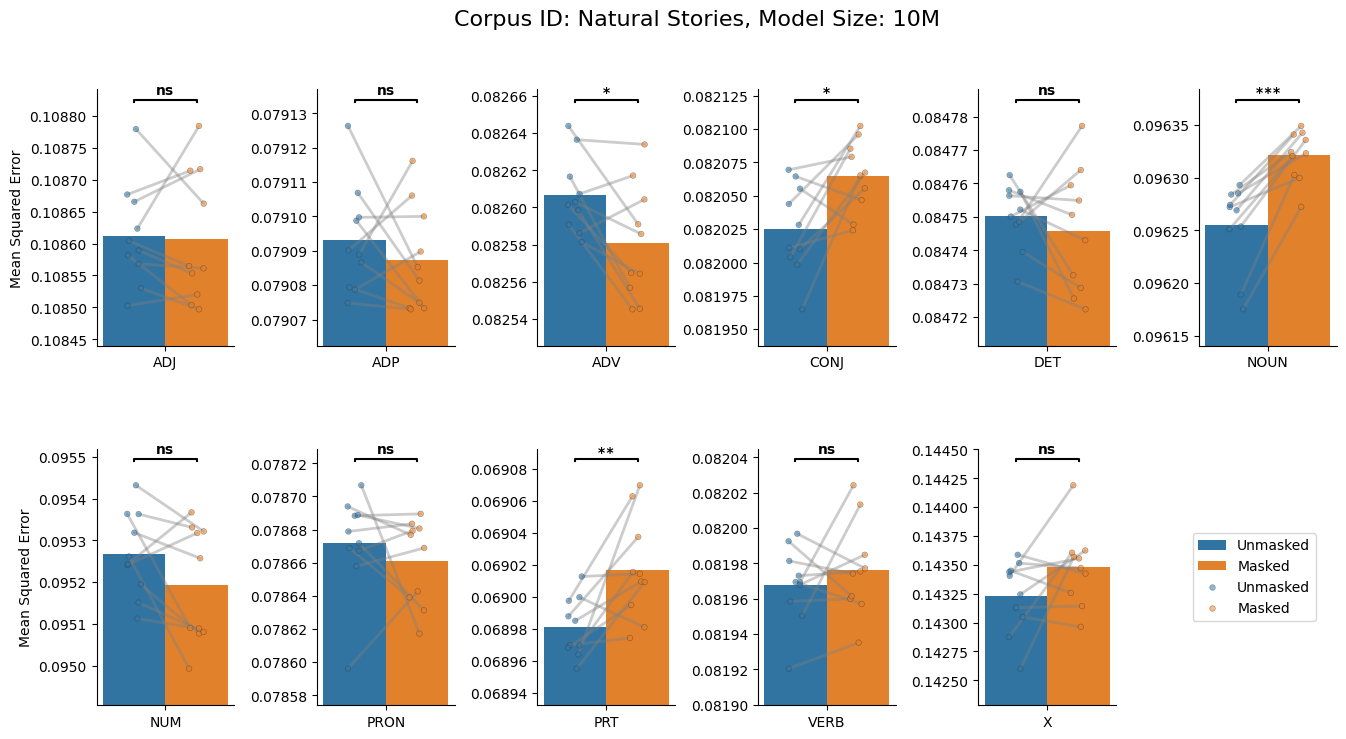

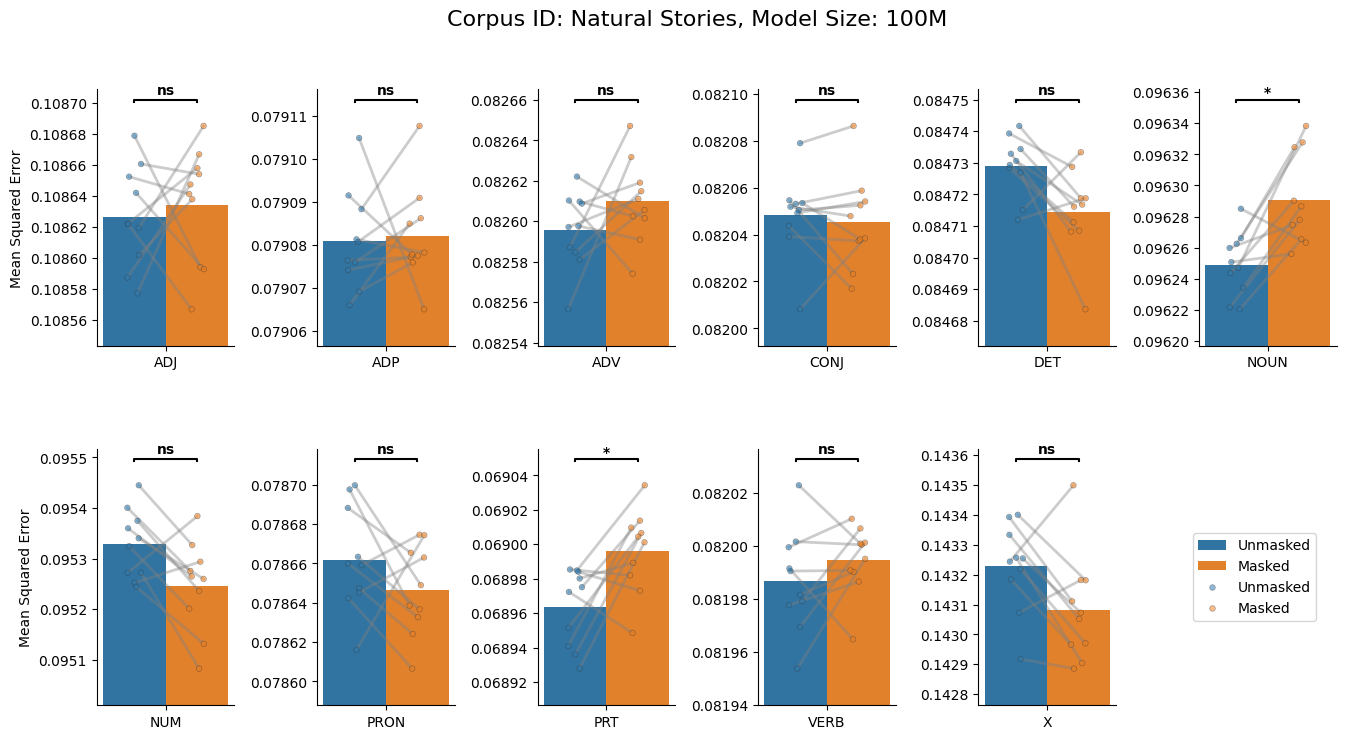

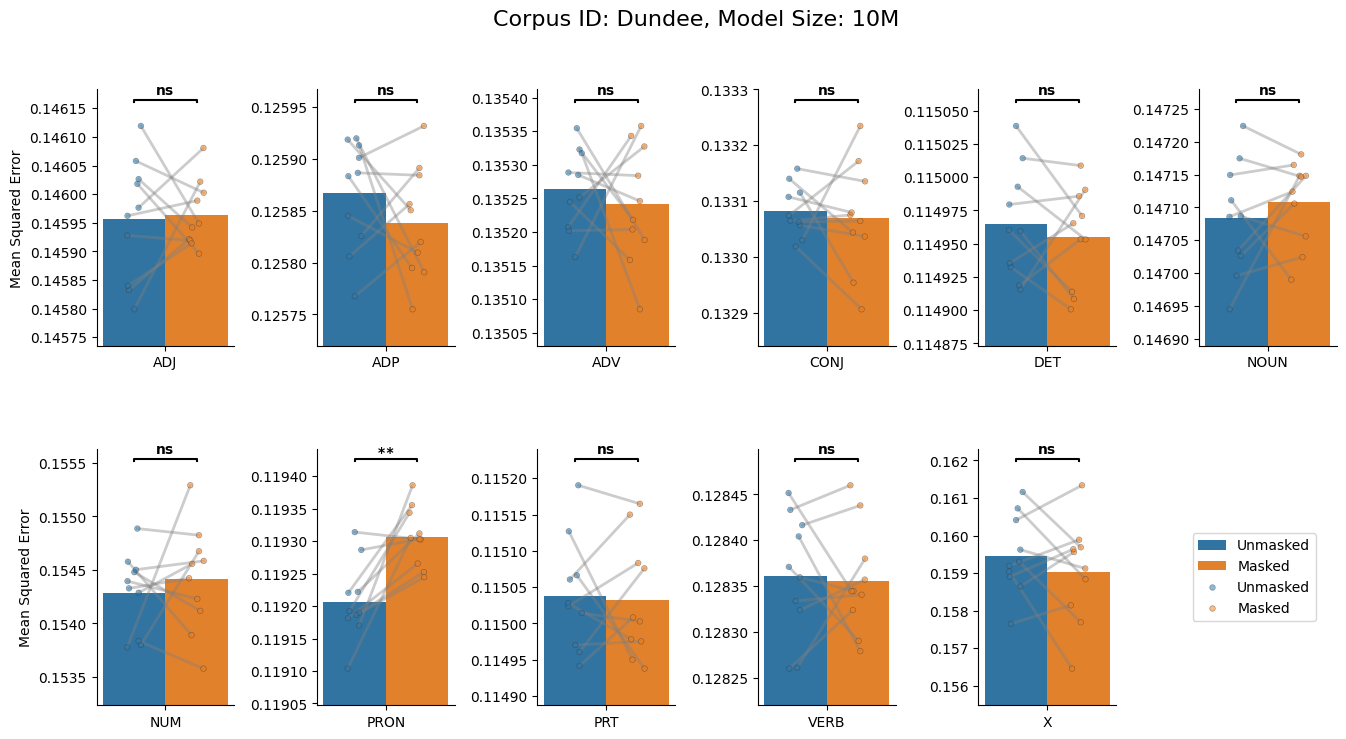

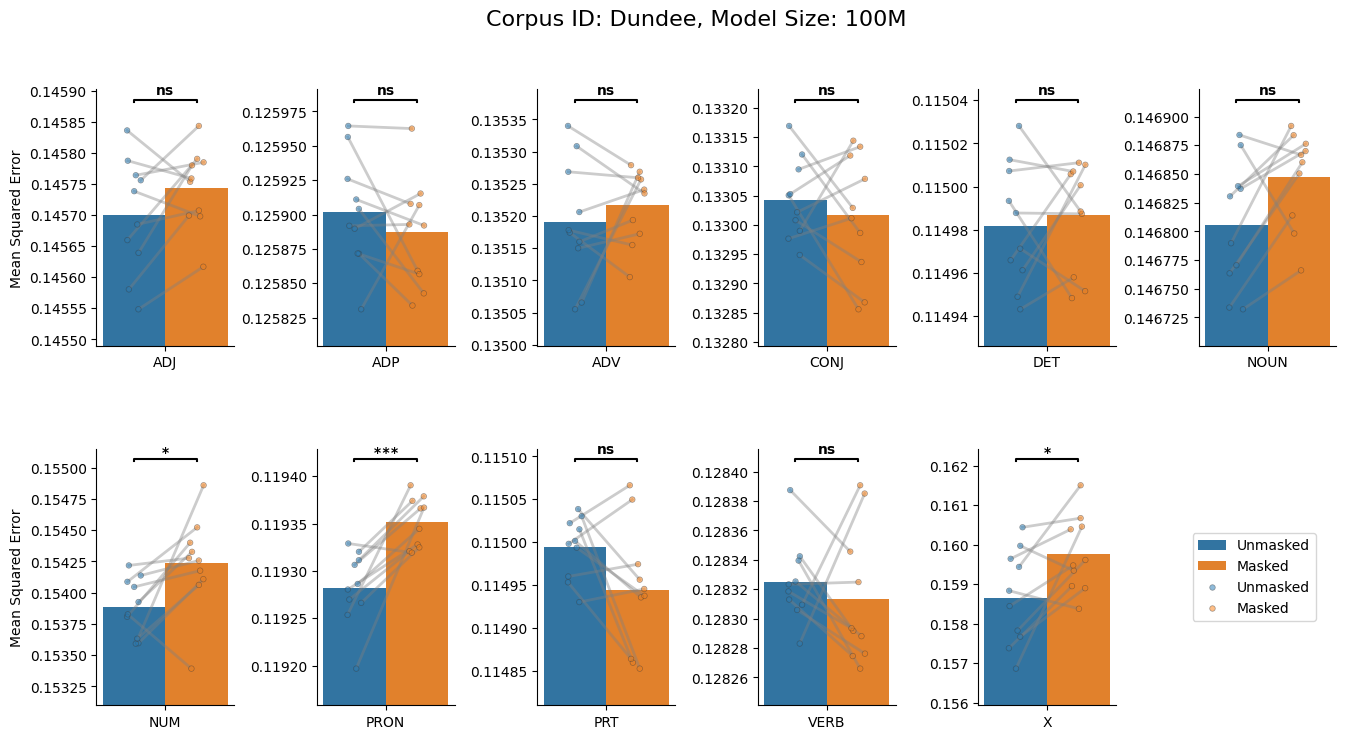

In [151]:
#4 Plots 2,2 Where 2 are for Corpus 1 and 2 are for Corpus 2. Each Having 10M and 100M

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
# fig, axes = plt.subplots(4, 1, figsize=(16, 8), sharex=True)

#Create 4x1 Subfigures and within each, 11 subplots for each POSTag

for i, corpus_id in tqdm(enumerate(["Natural Stories", "Dundee"])):
    for j, model_size in tqdm(enumerate(["10M", "100M"])):
        # ax = axes[i, j]
        # index = i * 2 + j
        # ax = axes[index]
        #ax = fig.add_subplot(2, 2, index + 1)
        #Create 11 plots for each POSTag
        fig, axes = plt.subplots(2, 6, figsize=(16, 8))
        fig.subplots_adjust(hspace=0.4, wspace=0.6)
        fig.suptitle(f"Corpus ID: {corpus_id}, Model Size: {model_size}", fontsize=16)
        for k, postag in tqdm(enumerate(POSTagdelta["POSTag"].unique())):
            ax = axes[k // 6, k % 6]
            subset = POSTagdelta[(POSTagdelta["CorpusID"] == corpus_id) & (POSTagdelta["Dataset"] == model_size) & (POSTagdelta["POSTag"] == postag)].copy()
            #Make POSTag as not categorical
            subset["POSTag"] = subset.POSTag.astype(str)
            sns.barplot(x="POSTag", y="MeanSquaredError", hue="MaskType", data=subset, ax=ax, errorbar=None)
            sns.stripplot(x="POSTag", y="MeanSquaredError", hue="MaskType",  data=subset, ax=ax, dodge=True, alpha=0.5, linewidth=0.5, size=4)
            # ax.set_title(f"POSTag: {postag}")
            
            ax.set_xlabel("")
            if k == 0 or k == 6:
                ax.set_ylabel("Mean Squared Error")
            else:
                ax.set_ylabel("")
            
            connect_dots_ib(ax, alpha=0.4, col='grey', linewidth=2)
            # Annotate the plot with significance stars
            #Find Max and Min Y limit as measure of max and and min delta
            max_y = subset["MeanSquaredError"].max()
            min_y = subset["MeanSquaredError"].min()
            
            ydelta = max_y - min_y

            delta_per = 0.2
            ax.set_ylim(min_y - ydelta * delta_per, max_y + ydelta * delta_per)

            annotate_given_colid_ib_gen(ax, subset, y_frac=0.95, h_frac=0.01, x_col="POSTag", pivot_col="MaskType", value_column="MeanSquaredError")
            sns.despine(ax=ax, top=True, right=True)
            # ax.get_legend().remove()
            if k!=10:
                ax.get_legend().remove()
            else:
                ax.legend(loc="center right", bbox_to_anchor=(2.5, 0.5))
        fig.delaxes(axes[1, 5])  # Remove the last empty subplot
        
        
        # Save the figure
        plot_name = f"POSTag_{corpus_id}_{model_size}_full_corpus_MSE.png"
        save_matplot_fig(fig, plot_name, dpi = 1000, folders_path="POSTag_MSE")

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

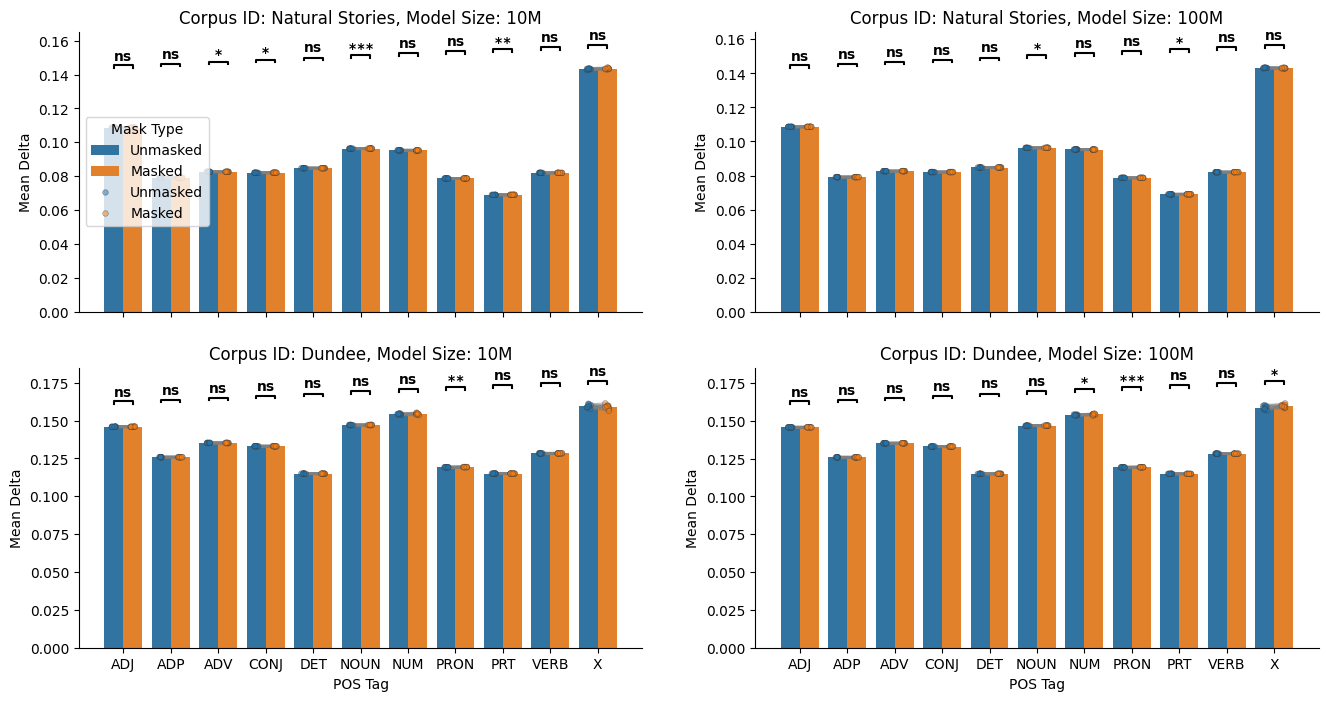

In [100]:
#4 Plots 2,2 Where 2 are for Corpus 1 and 2 are for Corpus 2. Each Having 10M and 100M

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

#Create 4x1 Subfigures and within each, 11 subplots for each POSTag

for i, corpus_id in tqdm(enumerate(["Natural Stories", "Dundee"])):
    for j, model_size in tqdm(enumerate(["10M", "100M"])):
        ax = axes[i, j]
        
        subset = POSTagdelta[(POSTagdelta["CorpusID"] == corpus_id) & (POSTagdelta["Dataset"] == model_size)]
        sns.barplot(x="POSTag", y="MeanSquaredError", hue="MaskType", data=subset, ax=ax, errorbar=None)
        sns.stripplot(x="POSTag", y="MeanSquaredError", hue="MaskType", data=subset, ax=ax, dodge=True, alpha=0.5, linewidth=0.5, size=4)
        ax.set_title(f"Corpus ID: {corpus_id}, Model Size: {model_size}")
        ax.set_xlabel("POS Tag")
        ax.set_ylabel("Mean Delta")
        ax.legend(title="Mask Type")
        connect_dots_ib(ax, alpha=0.4, col='grey', linewidth=2)
        # Annotate the plot with significance stars
        annotate_given_colid_ib_gen(ax, subset, y_frac=0.95, h_frac=0.01, x_col="POSTag", pivot_col="MaskType", value_column="MeanSquaredError")
        sns.despine(ax=ax, top=True, right=True)

        # if i == 1:
        #     #Set Y limit to 0.5
        #     ax.set_ylim(0.07, 0.1)
        # else:
        #     #Set Y limit to 0.5
        #     ax.set_ylim(0.07, 0.15)

        #Remove Legend
        if i == 0 and j == 0:
            ax.legend(title="Mask Type", loc='center left')
        else:
            ax.get_legend().remove()



In [ ]:
sample_model = model_list_df["ModelID"].unique()[0]
story_df = pd.read_sql("SELECT * FROM Story", conn)
from tqdm.auto import tqdm
def get_model_level_underover_df(model_id, conn):
        
    sample_test_df = pd.read_sql("SELECT * FROM RTModelPredict WHERE ModelID = {}".format(model_id), conn)
    sample_test_df = sample_test_df.merge(story_df, on="StoryWordID", how="left")
    sample_test_df["delta"] = sample_test_df["LogRT"] - sample_test_df["PredictedLogRT"]
    sample_test_df["delta"] = sample_test_df["delta"].astype(float)
    sample_test_df["delta_squared"] = sample_test_df["delta"] * sample_test_df["delta"]
    sample_test_df["delta_squared"] = sample_test_df["delta_squared"].astype(float)
    sample_test_df["UOP"] = sample_test_df["delta"].apply(lambda x: "UnderPredicted" if x > 0 else "OverPredicted")
    sample_test_df_groups = sample_test_df.groupby(["POSTag", "CorpusID", "ModelID", "UOP"]).agg({"delta": ["mean", "std"], "delta_squared": ["mean", "std", "sum", "count"]}).reset_index()

    sample_test_df_groups.columns = ["POSTag", "CorpusID", "ModelID", "UOP", "MeanDelta", "StdDevDelta", "MeanSquaredError", "StdDevSquaredError", "SumSquaredError", "Count"]

    return sample_test_df_groups
# sample_test_df_groups
# sample_test_df

# model_under_over_df = get_model_level_underover_df(sample_model, conn)
save_csv_path = "model_postag_underover_df_looped.csv"

def check_model_processed(model_id, save_csv_path):
    try:
        model_postag_underover_df = pd.read_csv(save_csv_path)
        model_postag_underover_df = model_postag_underover_df[model_postag_underover_df["ModelID"] == model_id]
        if not model_postag_underover_df.empty:
            return True
    except FileNotFoundError:
        pass
    return False

for model_id in tqdm(model_list_df["ModelID"].unique()):
    if check_model_processed(model_id, save_csv_path):
        print(f"Model {model_id} already processed.")
        continue
    model_postag_underover_df = get_model_level_underover_df(model_id, conn)
    model_postag_underover_df.to_csv(save_csv_path, mode='a', header=False, index=False)

Current Rows 1044562
After Removing Ignore Rows 1044562


,POSTag,CorpusID,ModelID,UOP,MeanDelta,StdDevDelta,MeanSquaredError,StdDevSquaredError,SumSquaredError,Count
0,ADJ,1,8465733,OverPredicted,-0.194933,0.144189,0.058789,0.091682,2737.041660,46557
1,ADJ,1,8465733,UnderPredicted,0.289749,0.314157,0.182646,0.435653,5720.642333,31321
2,ADJ,2,8465733,OverPredicted,-0.281912,0.244270,0.139138,0.241159,1687.044155,12125
3,ADJ,2,8465733,UnderPredicted,0.305079,0.244168,0.152686,0.223039,1708.096658,11187
4,ADP,1,8465733,OverPredicted,-0.171091,0.134341,0.047319,0.079445,2820.989896,59616
5,ADP,1,8465733,UnderPredicted,0.231273,0.261732,0.121990,0.332871,5379.745887,44100
6,ADP,2,8465733,OverPredicted,-0.256750,0.232918,0.120165,0.203442,1006.982305,8380
7,ADP,2,8465733,UnderPredicted,0.269355,0.243564,0.131868,0.233156,1051.646424,7975
8,ADV,1,8465733,OverPredicted,-0.176296,0.136822,0.049800,0.082168,1598.078791,32090
9,ADV,1,8465733,UnderPredicted,0.242851,0.262375,0.127815,0.319448,2976.930406,23291


In [48]:
model_under_over_df = pd.read_csv("model_postag_underover_df_looped.csv")
model_under_over_df = model_under_over_df.merge(model_list_df, on="ModelID", how="left")
model_under_over_df["CorpusID"] = model_under_over_df["CorpusID"].replace({1: "Natural Stories", 2: "Dundee"})
model_under_over_df["Dataset"] = model_under_over_df["Dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
model_under_over_df["MaskType"] = model_under_over_df["MaskType"].replace({"Non": "Unmasked", "exponential_new": "Masked"})
model_under_over_df["POSTag"] = pd.Categorical(model_under_over_df["POSTag"], ordered=True)
model_under_over_df["Dataset"] = pd.Categorical(model_under_over_df["Dataset"], ordered=True)
model_under_over_df["MaskType"] = pd.Categorical(model_under_over_df["MaskType"], ordered=True, categories=["Unmasked", "Masked"])
model_under_over_df["UOP"] = model_under_over_df["UOP"].replace({"UnderPredicted": "Under", "OverPredicted": "Over"})
model_under_over_df["UOP"] = pd.Categorical(model_under_over_df["UOP"], ordered=True, categories=["Under", "Over"])
model_under_over_df = model_under_over_df.rename(columns={"Seed":"seed"})
model_under_over_df = model_under_over_df.sort_values(by=["POSTag", "CorpusID", "Dataset", "MaskType", "seed", "UOP"])
model_under_over_df

,POSTag,CorpusID,ModelID,UOP,MeanDelta,StdDevDelta,MeanSquaredError,StdDevSquaredError,SumSquaredError,Count,BatchSize,Dataset,seed,MaskType
3,ADJ,Dundee,8465733,Under,0.305079,0.244168,0.152686,0.223039,1708.096658,11187,32,100M,9,Unmasked
2,ADJ,Dundee,8465733,Over,-0.281912,0.244270,0.139138,0.241159,1687.044155,12125,32,100M,9,Unmasked
179,ADJ,Dundee,8465604,Under,0.304585,0.244327,0.152463,0.222883,1708.342690,11205,32,100M,42,Unmasked
178,ADJ,Dundee,8465604,Over,-0.282332,0.244559,0.139516,0.241869,1689.114716,12107,32,100M,42,Unmasked
355,ADJ,Dundee,8465611,Under,0.304751,0.244128,0.152467,0.222862,1707.168384,11197,32,100M,466,Unmasked
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,X,Natural Stories,6839428,Over,-0.241788,0.172771,0.088231,0.146944,32.557066,369,32,10M,6747,Masked
1581,X,Natural Stories,6839431,Under,0.343139,0.317011,0.217878,0.397292,60.352082,277,32,10M,11111,Masked
1580,X,Natural Stories,6839431,Over,-0.242188,0.174072,0.088874,0.147339,32.794558,369,32,10M,11111,Masked
1757,X,Natural Stories,6839427,Under,0.343018,0.318056,0.218454,0.398621,60.293438,276,32,10M,46674,Masked


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

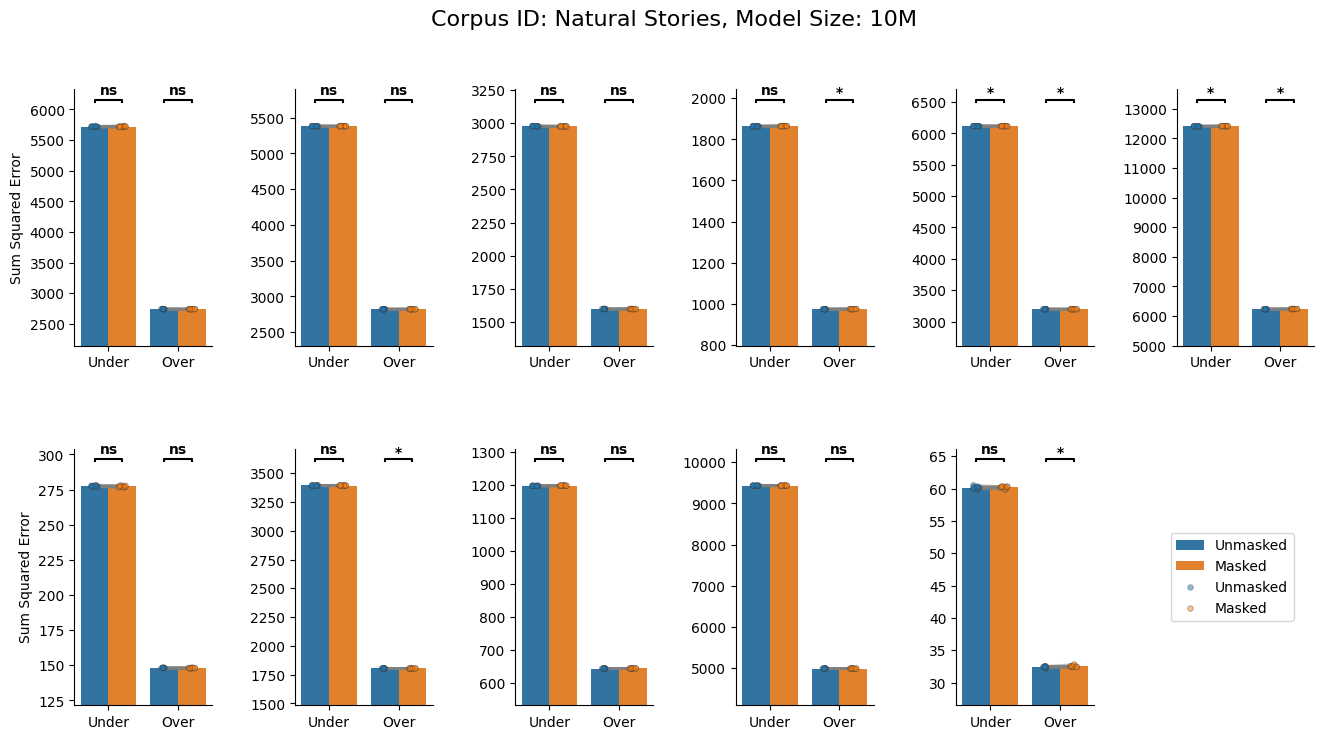

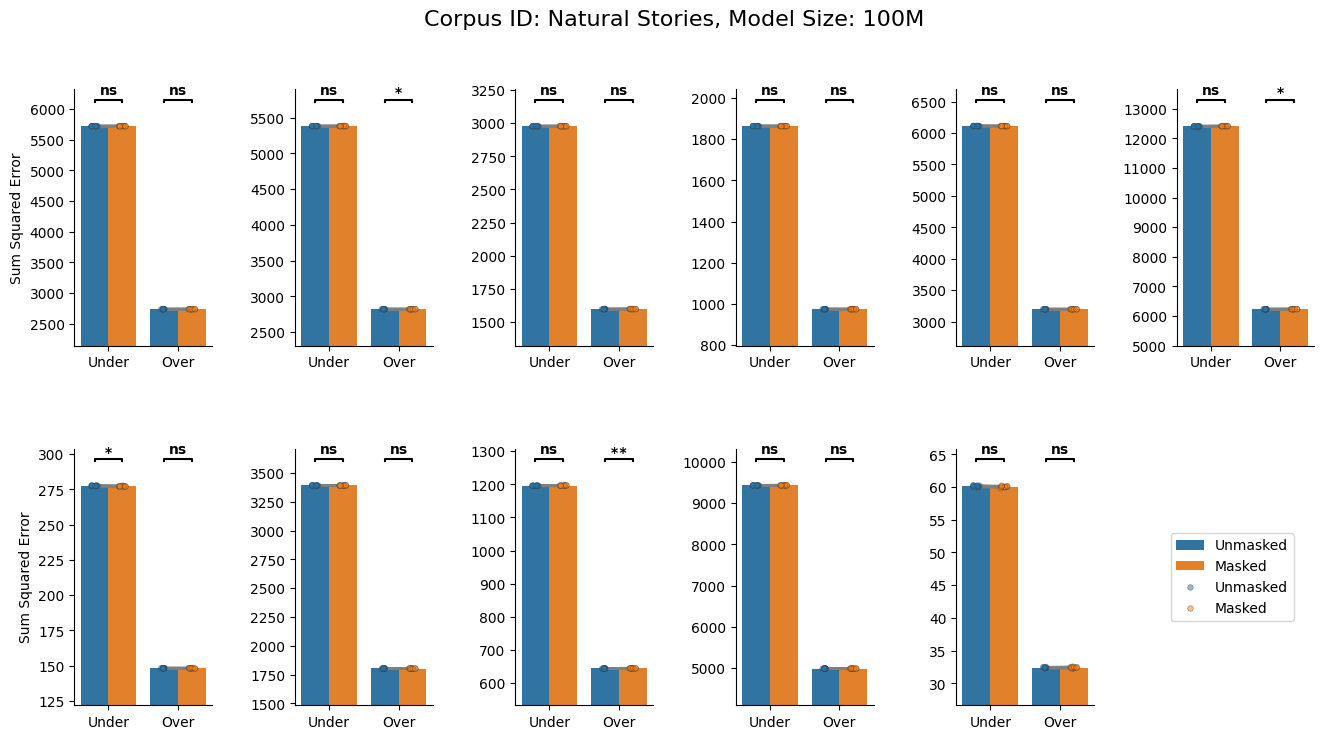

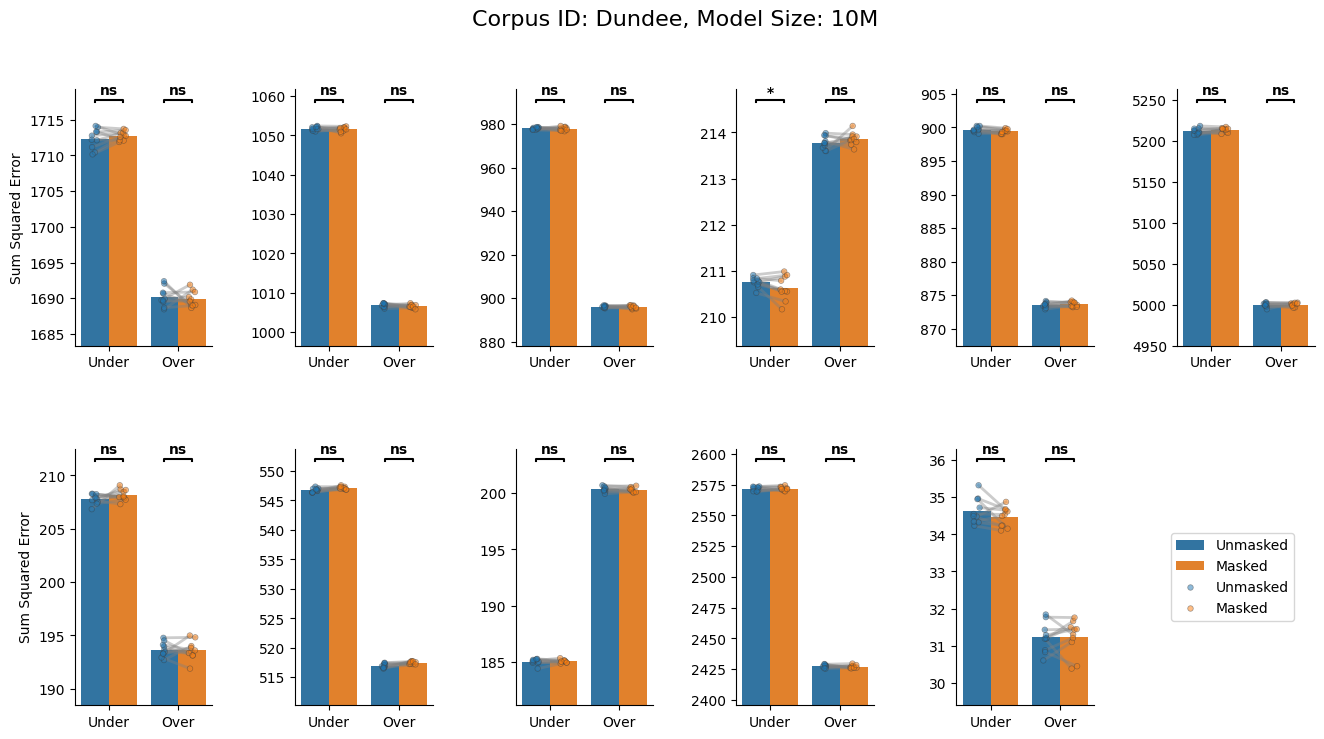

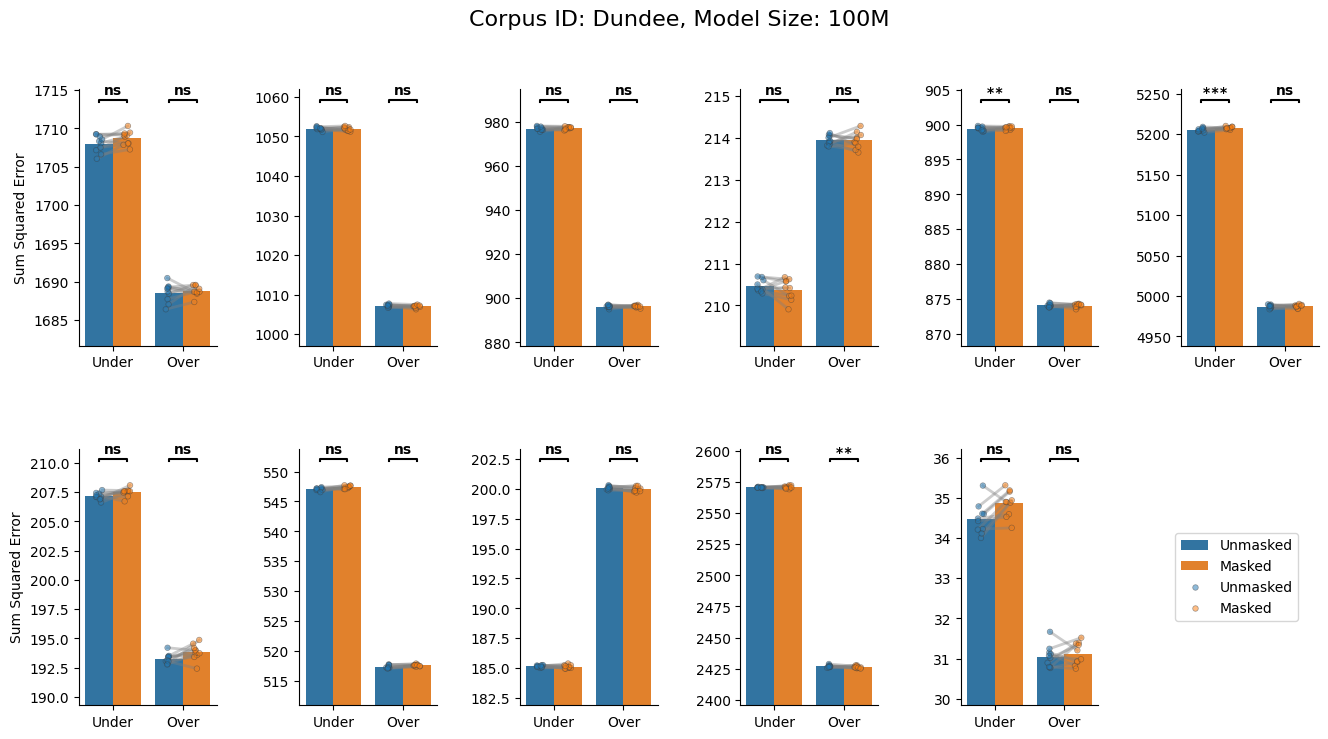

In [ ]:

for i, corpus_id in tqdm(enumerate(["Natural Stories", "Dundee"])):
    for j, model_size in tqdm(enumerate(["10M", "100M"])):
        
        # ax = axes[i, j]
        # index = i * 2 + j
        # ax = axes[index]
        #ax = fig.add_subplot(2, 2, index + 1)
        #Create 11 plots for each POSTag
        fig, axes = plt.subplots(2, 6, figsize=(16, 8))
        fig.subplots_adjust(hspace=0.4, wspace=0.6)
        fig.suptitle(f"Corpus ID: {corpus_id}, Model Size: {model_size}", fontsize=16)
        for k, postag in tqdm(enumerate(model_under_over_df["POSTag"].unique())):
            ax = axes[k // 6, k % 6]
            subset = model_under_over_df[(model_under_over_df["CorpusID"] == corpus_id) & (model_under_over_df["Dataset"] == model_size) & (model_under_over_df["POSTag"] == postag)].copy()
            #print(subset)
            #Make POSTag as not categorical
            subset["POSTag"] = subset.POSTag.astype(str)
            sns.barplot(x="UOP", y="SumSquaredError", hue="MaskType", data=subset, ax=ax, errorbar=None)
            sns.stripplot(x="UOP", y="SumSquaredError", hue="MaskType",  data=subset, ax=ax, dodge=True, alpha=0.5, linewidth=0.5, size=4)
            # ax.set_title(f"POSTag: {postag}")
            
            ax.set_xlabel("")
            if k == 0 or k == 6:
                ax.set_ylabel("Sum Squared Error")
            else:
                ax.set_ylabel("")
            
            connect_dots_ib(ax, alpha=0.4, col='grey', linewidth=2)
            # Annotate the plot with significance stars
            #Find Max and Min Y limit as measure of max and and min delta
            max_y = subset["SumSquaredError"].max()
            min_y = subset["SumSquaredError"].min()
            ydelta = max_y - min_y
            delta_per = 0.2
            ax.set_ylim(min_y - ydelta * delta_per, max_y + ydelta * delta_per)
            annotate_given_colid_ib_gen(ax, subset, y_frac=0.95, h_frac=0.01, x_col="UOP", pivot_col="MaskType", value_column="SumSquaredError")
            sns.despine(ax=ax, top=True, right=True)
            # ax.get_legend().remove()
            if k!=10:
                ax.get_legend().remove()
            else:
                ax.legend(loc="center right", bbox_to_anchor=(2.5, 0.5))
        fig.delaxes(axes[1, 5])




0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

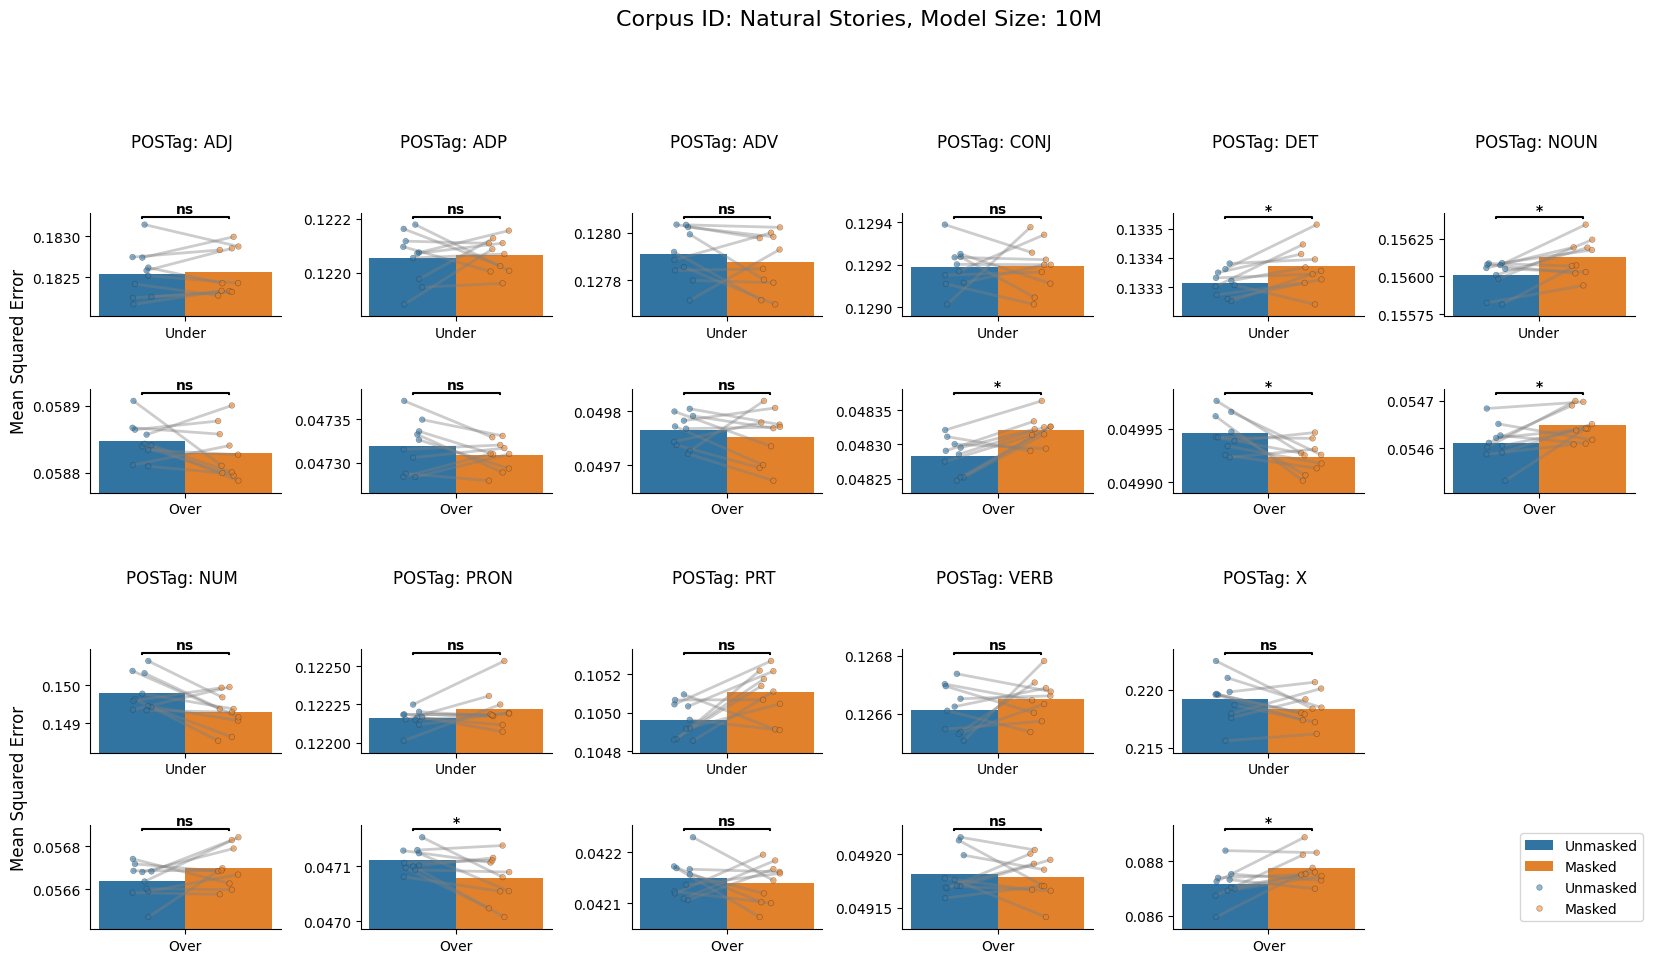

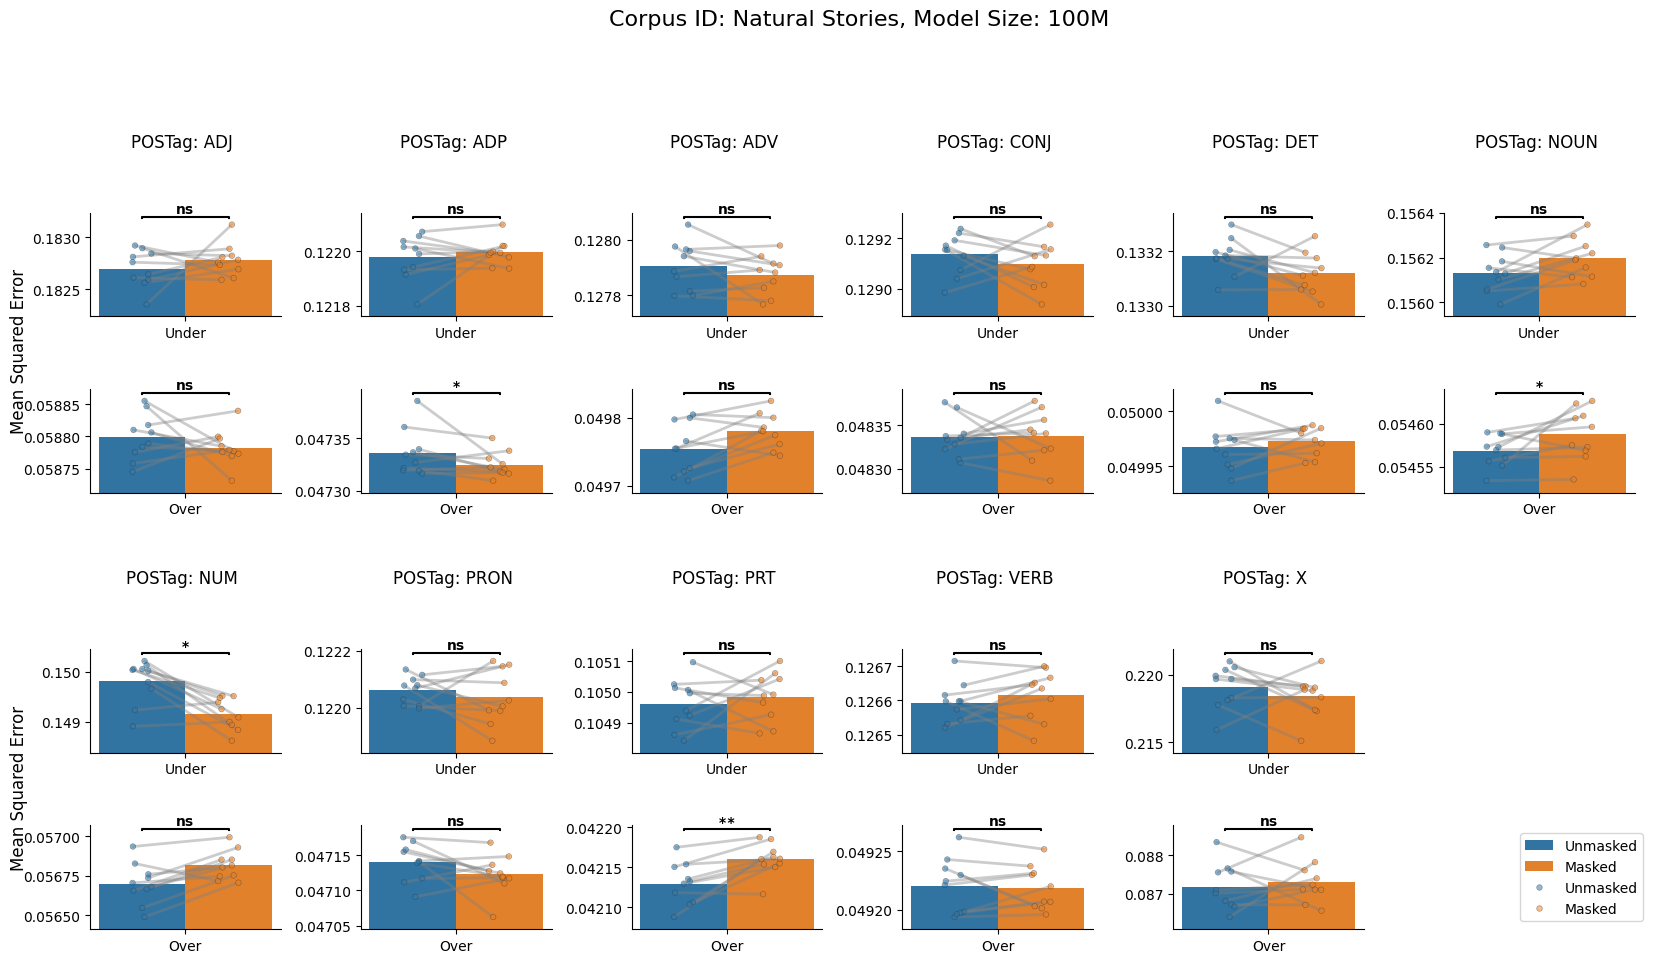

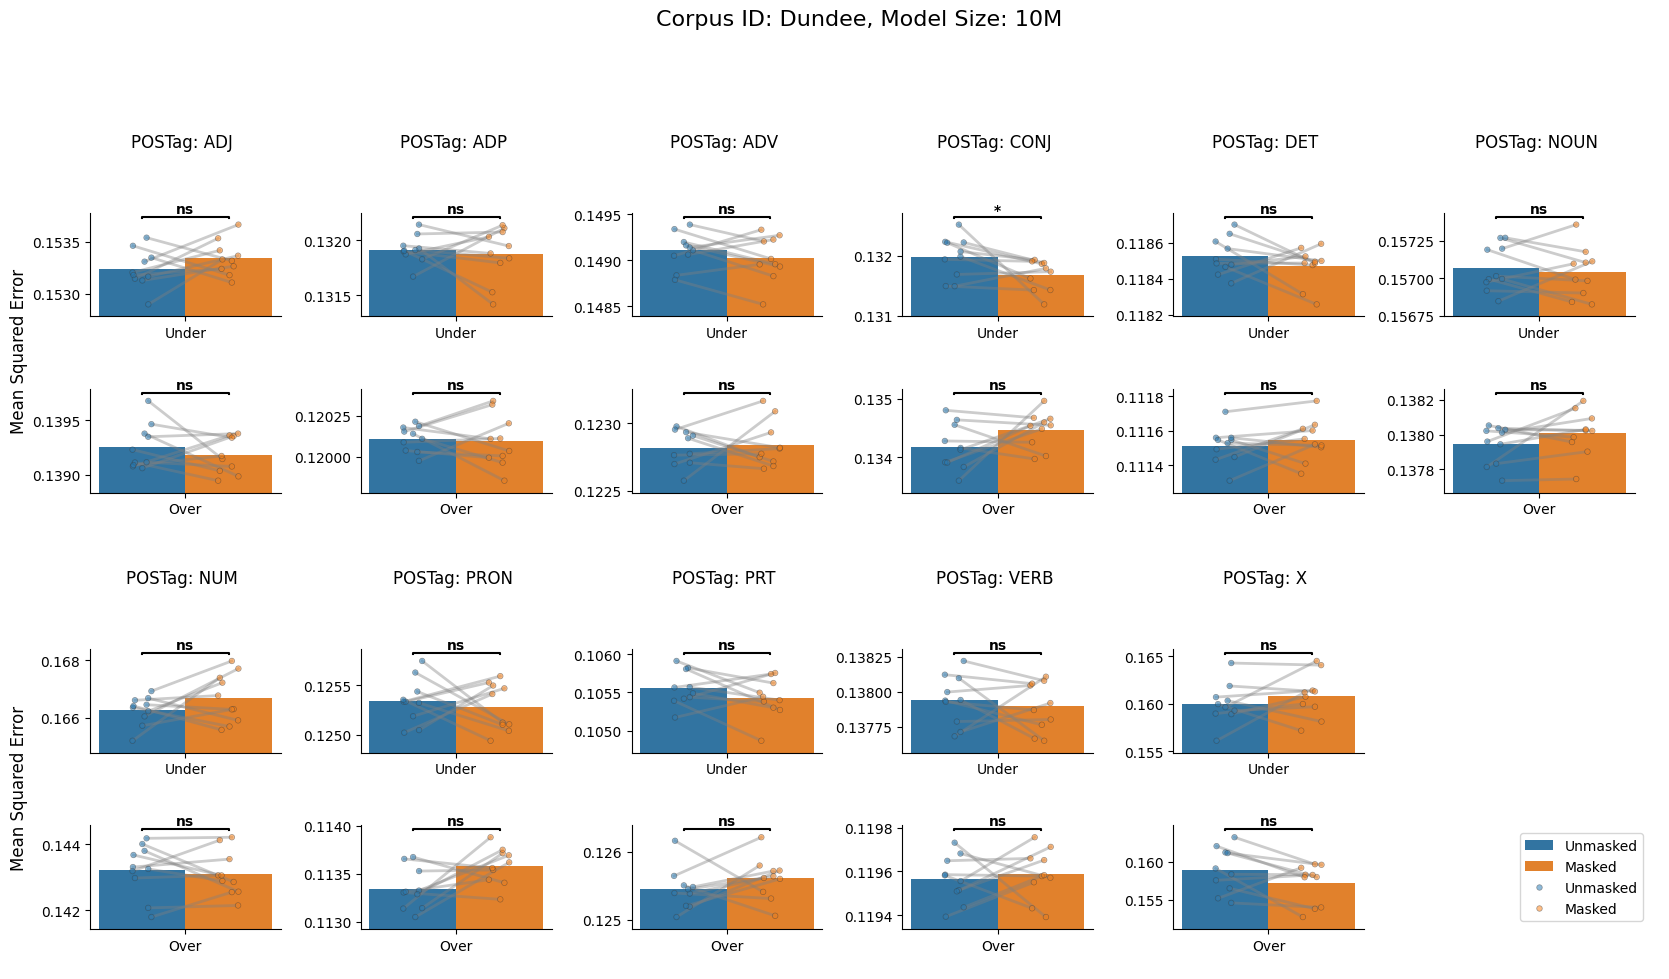

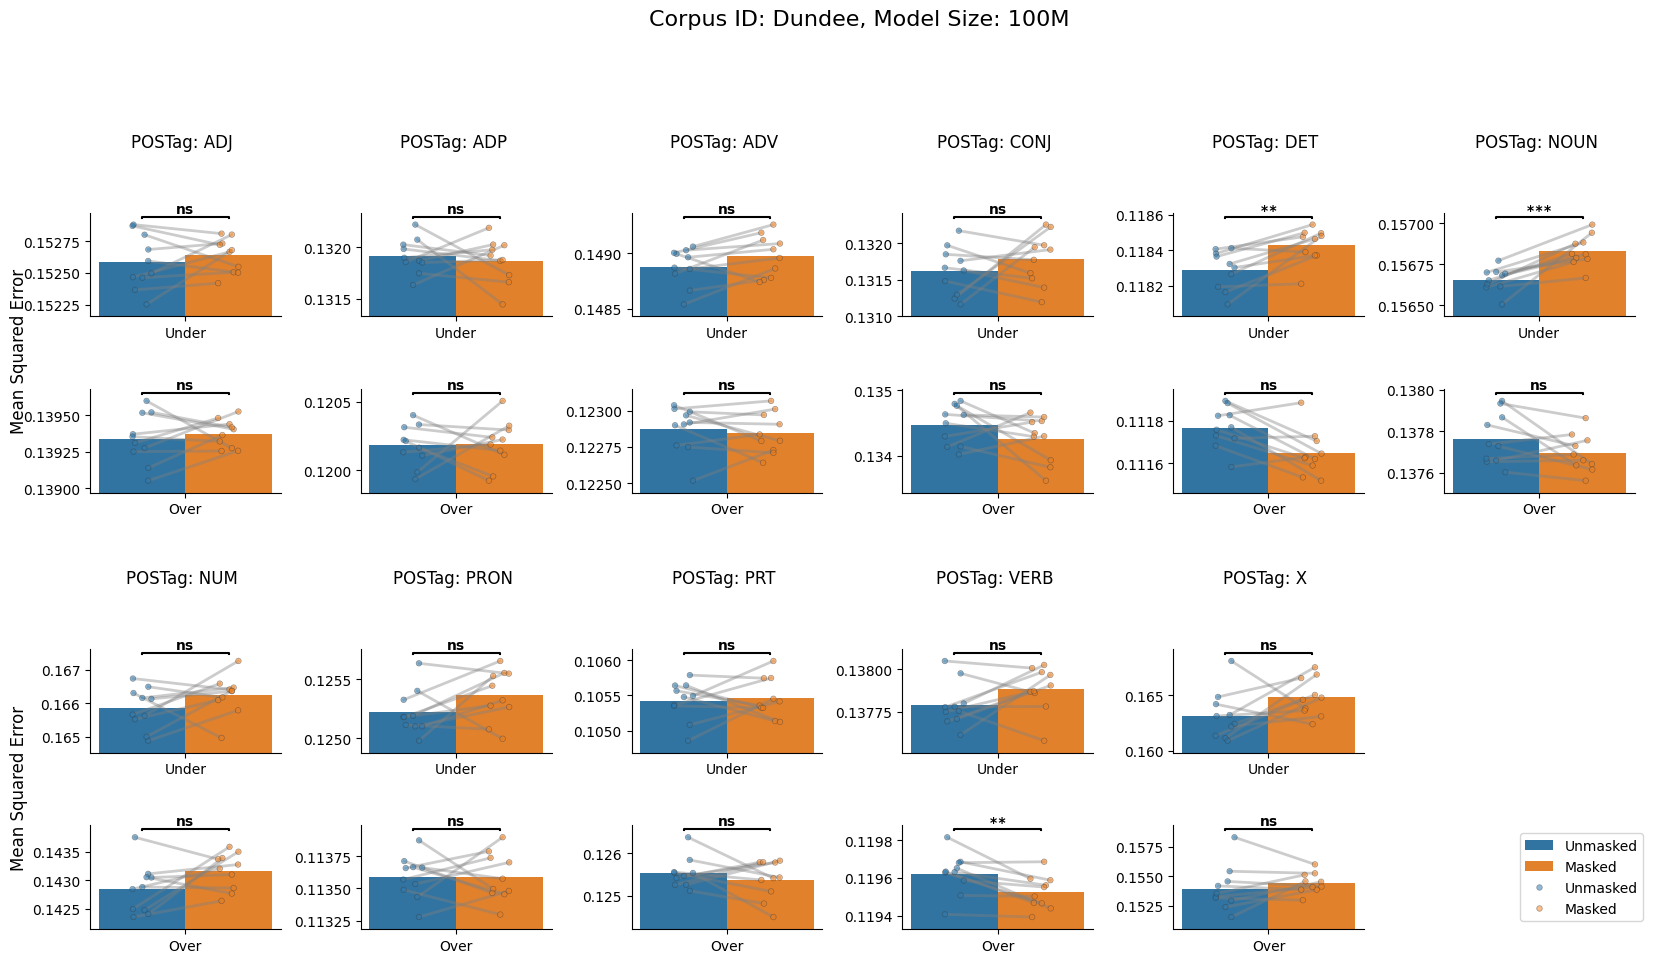

In [155]:

for i, corpus_id in tqdm(enumerate(["Natural Stories", "Dundee"])):
    for j, model_size in tqdm(enumerate(["10M", "100M"])):
        # if i!=0 or j!=0:
        #     break
        # ax = axes[i, j]
        # index = i * 2 + j
        # ax = axes[index]
        #ax = fig.add_subplot(2, 2, index + 1)
        #Create 11 plots for each POSTag
        # fig, axes = plt.subplots(2, 6, figsize=(16, 8))
        #Create 12 subfigures in 2x6
        fig = plt.figure(figsize=(16, 8))
        subfigs = fig.subfigures(2, 6, wspace=0.1, hspace=0.2)
        #print(subfigs)
        #fig.subplots_adjust(hspace=0.4, wspace=0.6)
        fig.suptitle(f"Corpus ID: {corpus_id}, Model Size: {model_size}", fontsize=16, y = 1.2)
        for k, postag in tqdm(enumerate(model_under_over_df["POSTag"].unique())):
            #ax = axes[k // 6, k % 6]
            axs = subfigs[k // 6, k % 6].subplots(2, 1)
            subfigs[k // 6, k % 6].subplots_adjust(hspace=0.7, wspace=0.6)
            #axs = subfigs[k].subplots(2, 1)
            #Sub fig title
            
            if k == 0 or k == 6:
                subfigs[k//6, k%6].supylabel("Mean Squared Error", x=-0.2)
            
            # subfigs[k].suptitle(f"POSTag: {postag}", fontsize=12)

            for l, uop in enumerate(["Under", "Over"]):
                ax = axs[l] 
                subset = model_under_over_df[(model_under_over_df["CorpusID"] == corpus_id) & (model_under_over_df["Dataset"] == model_size) & (model_under_over_df["POSTag"] == postag) & (model_under_over_df["UOP"] == uop)].copy()
                
                #print(subset)
                #Make POSTag as not categorical
                subset["POSTag"] = subset.POSTag.astype(str)
                subset["UOP"] = subset.UOP.astype(str)
                sns.barplot(x="UOP", y="MeanSquaredError", hue="MaskType", data=subset, ax=ax, errorbar=None)
                sns.stripplot(x="UOP", y="MeanSquaredError", hue="MaskType",  data=subset, ax=ax, dodge=True, alpha=0.5, linewidth=0.5, size=4)
                # ax.set_title(f"POSTag: {postag}")
                
                ax.set_xlabel("")
                if k == 0 or k == 6:
                    # ax.set_ylabel("Sum Squared Error")
                    ax.set_ylabel("")
                else:
                    ax.set_ylabel("")
                
                connect_dots_ib(ax, alpha=0.4, col='grey', linewidth=2)
                # Annotate the plot with significance stars
                #Find Max and Min Y limit as measure of max and and min delta
                max_y = subset["MeanSquaredError"].max()
                min_y = subset["MeanSquaredError"].min()
                ydelta = max_y - min_y
                delta_per = 0.15
                ax.set_ylim(min_y - ydelta * delta_per, max_y + ydelta * delta_per)
                annotate_given_colid_ib_gen(ax, subset, y_frac=0.95, h_frac=0.01, x_col="UOP", pivot_col="MaskType", value_column="MeanSquaredError")
                sns.despine(ax=ax, top=True, right=True)
                # ax.get_legend().remove()
                if k!=10:
                    ax.get_legend().remove()
                else:
                    if l ==1:
                        ax.legend(loc="center right", bbox_to_anchor=(2.5, 0.5))
                    else:
                        ax.get_legend().remove()
            
            subfigs[k//6, k%6].suptitle(f"POSTag: {postag}", fontsize=12, y=1.1)
        #fig.delaxes(axes[1, 5])

        # Save the figure
                # Save the figure
        plot_name = f"POSTag_{corpus_id}_{model_size}_underover_separated_MSE.png"
        save_matplot_fig(fig, plot_name, dpi = 1000, folders_path="POSTag_UnderOver_MSE")


In [96]:
sample_model = model_list_df["ModelID"].unique()[0]
story_df = pd.read_sql("SELECT * FROM Story", conn)
from tqdm.auto import tqdm
def get_model_level_df(model_id, conn):
        
    sample_test_df = pd.read_sql("SELECT * FROM RTModelPredict WHERE ModelID = {}".format(model_id), conn)
    sample_test_df = sample_test_df.merge(story_df, on="StoryWordID", how="left")
    sample_test_df["delta"] = sample_test_df["LogRT"] - sample_test_df["PredictedLogRT"]
    sample_test_df["delta"] = sample_test_df["delta"].astype(float)
    sample_test_df["delta_squared"] = sample_test_df["delta"] * sample_test_df["delta"]
    sample_test_df["delta_squared"] = sample_test_df["delta_squared"].astype(float)
    #sample_test_df["UOP"] = sample_test_df["delta"].apply(lambda x: "UnderPredicted" if x > 0 else "OverPredicted")
    sample_test_df_groups = sample_test_df.groupby(["POSTag", "CorpusID", "ModelID"]).agg({"delta": ["mean", "std"], "delta_squared": ["mean", "std", "sum", "count"]}).reset_index()

    sample_test_df_groups.columns = ["POSTag", "CorpusID", "ModelID", "MeanDelta", "StdDevDelta", "MeanSquaredError", "StdDevSquaredError", "SumSquaredError", "Count"]

    return sample_test_df_groups
# sample_test_df_groups
# sample_test_df

# model_under_over_df = get_model_level_underover_df(sample_model, conn)
save_csv_path = "model_postag_df_looped.csv"

def check_model_processed(model_id, save_csv_path):
    try:
        model_postag_df = pd.read_csv(save_csv_path)
        model_postag_df = model_postag_df[model_postag_df["ModelID"] == model_id]
        if not model_postag_df.empty:
            return True
    except FileNotFoundError:
        pass
    return False

for model_id in tqdm(model_list_df["ModelID"].unique()):
    if check_model_processed(model_id, save_csv_path):
        print(f"Model {model_id} already processed.")
        continue
    model_postag_df = get_model_level_df(model_id, conn)
    model_postag_df.to_csv(save_csv_path, mode='a', header=False, index=False)
# model_postag_df = get_model_level_df(model_list_df["ModelID"].unique()[0], conn)

# model_postag_df.to_csv(save_csv_path, index=False)
# model_postag_df


  0%|          | 0/40 [00:00<?, ?it/s]

Model 8465733 already processed.


In [105]:
sample_model = model_list_df["ModelID"].unique()[0]
story_df = pd.read_sql("SELECT * FROM Story", conn)
from tqdm.auto import tqdm
def get_model_ner_level_df(model_id, conn):
        
    sample_test_df = pd.read_sql("SELECT * FROM RTModelPredict WHERE ModelID = {}".format(model_id), conn)
    sample_test_df = sample_test_df.merge(story_df, on="StoryWordID", how="left")
    sample_test_df["delta"] = sample_test_df["LogRT"] - sample_test_df["PredictedLogRT"]
    sample_test_df["delta"] = sample_test_df["delta"].astype(float)
    sample_test_df["delta_squared"] = sample_test_df["delta"] * sample_test_df["delta"]
    sample_test_df["delta_squared"] = sample_test_df["delta_squared"].astype(float)
    sample_test_df["NERGroup"] = sample_test_df["NERTag"].apply(lambda x: "Not_NER" if x == "" else "NER")
    #sample_test_df["UOP"] = sample_test_df["delta"].apply(lambda x: "UnderPredicted" if x > 0 else "OverPredicted")
    sample_test_df_groups = sample_test_df.groupby(["NERGroup", "CorpusID", "ModelID"]).agg({"delta": ["mean", "std"], "delta_squared": ["mean", "std", "sum", "count"]}).reset_index()

    sample_test_df_groups.columns = ["NERGroup", "CorpusID", "ModelID", "MeanDelta", "StdDevDelta", "MeanSquaredError", "StdDevSquaredError", "SumSquaredError", "Count"]

    return sample_test_df_groups
# sample_test_df_groups
# sample_test_df

# model_under_over_df = get_model_level_underover_df(sample_model, conn)
save_csv_path = "model_nertag_df_looped.csv"

def check_model_processed(model_id, save_csv_path):
    try:
        model_nertag_df = pd.read_csv(save_csv_path)
        model_nertag_df = model_nertag_df[model_nertag_df["ModelID"] == model_id]
        if not model_nertag_df.empty:
            return True
    except FileNotFoundError:
        pass
    return False

for model_id in tqdm(model_list_df["ModelID"].unique()):
    if check_model_processed(model_id, save_csv_path):
        print(f"Model {model_id} already processed.")
        continue
    model_nertag_df = get_model_ner_level_df(model_id, conn)
    model_nertag_df.to_csv(save_csv_path, mode='a', header=False, index=False)


# model_nertag_df = get_model_ner_level_df(model_list_df["ModelID"].unique()[0], conn)

# model_nertag_df.to_csv(save_csv_path, index=False)
# model_nertag_df


  0%|          | 0/40 [00:00<?, ?it/s]

Model 8465733 already processed.


In [107]:
#Block for same fig as POSTag but for NER

model_nertag_df = pd.read_csv("model_nertag_df_looped.csv")
model_nertag_df = model_nertag_df.merge(model_list_df, on="ModelID", how="left")
model_nertag_df["CorpusID"] = model_nertag_df["CorpusID"].replace({1: "Natural Stories", 2: "Dundee"})
model_nertag_df["Dataset"] = model_nertag_df["Dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
model_nertag_df["MaskType"] = model_nertag_df["MaskType"].replace({"Non": "Unmasked", "exponential_new": "Masked"})
#model_nertag_df["POSTag"] = pd.Categorical(model_nertag_df["POSTag"], ordered=True)
model_nertag_df["Dataset"] = pd.Categorical(model_nertag_df["Dataset"], ordered=True)
model_nertag_df["MaskType"] = pd.Categorical(model_nertag_df["MaskType"], ordered=True, categories=["Unmasked", "Masked"])
model_nertag_df["NERGroup"] = model_nertag_df["NERGroup"].replace({"Not_NER": "Not NER", "NER": "NER"})
model_nertag_df["NERGroup"] = pd.Categorical(model_nertag_df["NERGroup"], ordered=True, categories=["Not NER", "NER"])
model_nertag_df = model_nertag_df.rename(columns={"Seed":"seed"})
model_nertag_df = model_nertag_df.sort_values(by=["NERGroup", "CorpusID", "Dataset", "MaskType", "seed"])
model_nertag_df


,NERGroup,CorpusID,ModelID,MeanDelta,StdDevDelta,MeanSquaredError,StdDevSquaredError,SumSquaredError,Count,BatchSize,Dataset,seed,MaskType
3,Not NER,Dundee,8465733,0.001031,0.367049,0.134725,0.223599,23510.053454,174504,32,100M,9,Unmasked
19,Not NER,Dundee,8465604,0.001103,0.367016,0.134701,0.223592,23505.882591,174504,32,100M,42,Unmasked
35,Not NER,Dundee,8465611,0.001064,0.367026,0.134709,0.223601,23507.184294,174504,32,100M,466,Unmasked
51,Not NER,Dundee,8465607,0.001055,0.367007,0.134694,0.223637,23504.727726,174504,32,100M,616,Unmasked
67,Not NER,Dundee,8465610,0.001043,0.366982,0.134676,0.223565,23501.515088,174504,32,100M,869,Unmasked
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,NER,Natural Stories,6681944,0.027602,0.334245,0.112479,0.302346,5501.362392,48910,32,10M,1337,Masked
108,NER,Natural Stories,6839424,0.027515,0.334125,0.112395,0.301867,5497.219953,48910,32,10M,2347,Masked
124,NER,Natural Stories,6839428,0.028149,0.334189,0.112472,0.302477,5501.008732,48910,32,10M,6747,Masked
140,NER,Natural Stories,6839431,0.028240,0.334251,0.112519,0.302357,5503.298746,48910,32,10M,11111,Masked


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

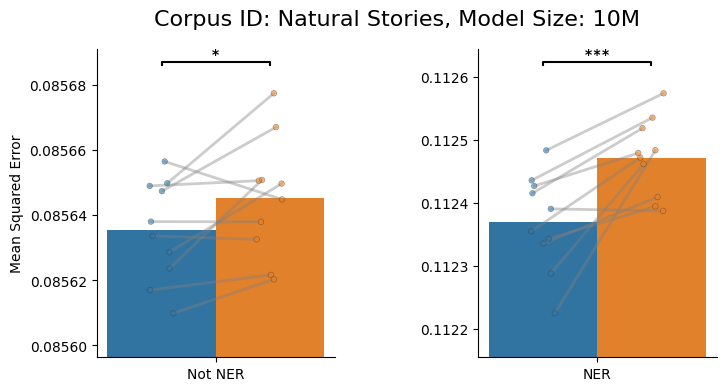

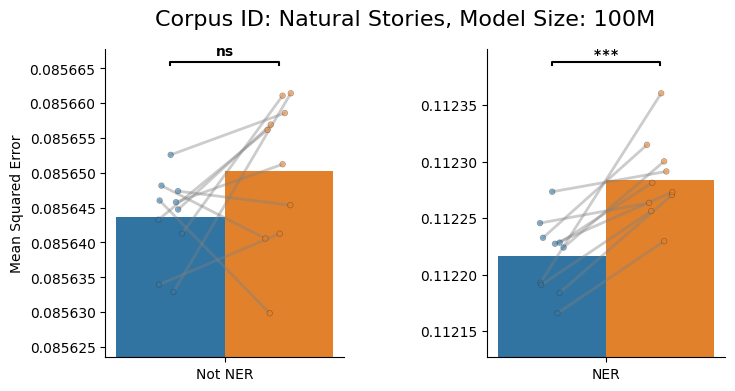

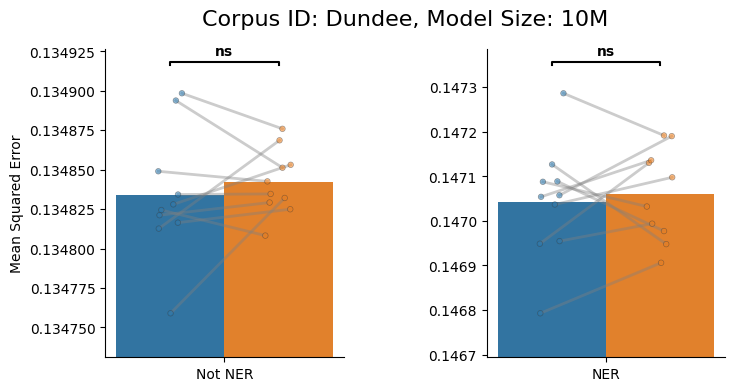

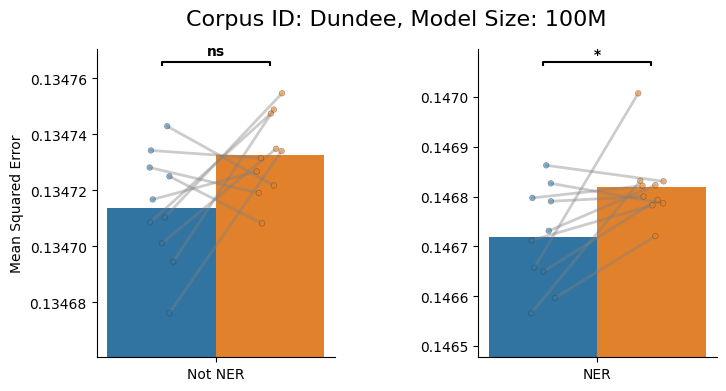

In [157]:
#4 Plots 2,2 Where 2 are for Corpus 1 and 2 are for Corpus 2. Each Having 10M and 100M

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
# fig, axes = plt.subplots(4, 1, figsize=(16, 8), sharex=True)

#Create 4x1 Subfigures and within each, 11 subplots for each POSTag

for i, corpus_id in tqdm(enumerate(["Natural Stories", "Dundee"])):
    for j, model_size in tqdm(enumerate(["10M", "100M"])):
        # ax = axes[i, j]
        # index = i * 2 + j
        # ax = axes[index]
        #ax = fig.add_subplot(2, 2, index + 1)
        #Create 11 plots for each POSTag
        fig, axes = plt.subplots(1, 2, figsize=(8,4))
        fig.subplots_adjust(hspace=0.4, wspace=0.6)
        fig.suptitle(f"Corpus ID: {corpus_id}, Model Size: {model_size}", fontsize=16)
        for k, postag in tqdm(enumerate(model_nertag_df["NERGroup"].unique())):
            #ax = axes[k // 6, k % 6]
            ax = axes[k]
            #subset = POSTagdelta[(POSTagdelta["CorpusID"] == corpus_id) & (POSTagdelta["Dataset"] == model_size) & (POSTagdelta["POSTag"] == postag)].copy()
            subset = model_nertag_df[(model_nertag_df["CorpusID"] == corpus_id) & (model_nertag_df["Dataset"] == model_size) & (model_nertag_df["NERGroup"] == postag)].copy()
            #Make POSTag as not categorical
            subset["NERGroup"] = subset.NERGroup.astype(str)
            sns.barplot(x="NERGroup", y="MeanSquaredError", hue="MaskType", data=subset, ax=ax, errorbar=None)
            sns.stripplot(x="NERGroup", y="MeanSquaredError", hue="MaskType",  data=subset, ax=ax, dodge=True, alpha=0.5, linewidth=0.5, size=4)
            # ax.set_title(f"POSTag: {postag}")
            
            ax.set_xlabel("")
            if k == 0 or k == 6:
                ax.set_ylabel("Mean Squared Error")
            else:
                ax.set_ylabel("")
            
            connect_dots_ib(ax, alpha=0.4, col='grey', linewidth=2)
            # Annotate the plot with significance stars
            #Find Max and Min Y limit as measure of max and and min delta
            max_y = subset["MeanSquaredError"].max()
            min_y = subset["MeanSquaredError"].min()
            
            ydelta = max_y - min_y

            delta_per = 0.2
            ax.set_ylim(min_y - ydelta * delta_per, max_y + ydelta * delta_per)

            annotate_given_colid_ib_gen(ax, subset, y_frac=0.95, h_frac=0.01, x_col="NERGroup", pivot_col="MaskType", value_column="MeanSquaredError")
            sns.despine(ax=ax, top=True, right=True)
            # ax.get_legend().remove()
            if k!=10:
                ax.get_legend().remove()
            else:
                ax.legend(loc="center right", bbox_to_anchor=(2.5, 0.5))
        #fig.delaxes(axes[1, 5])  # Remove the last empty subplot

        # Save the figure
        plot_name = f"NERGroup_{corpus_id}_{model_size}_full_corpus_MSE.png"
        save_matplot_fig(fig, plot_name, dpi = 1000, folders_path="NERGroup_MSE")
        

In [116]:
sample_model = model_list_df["ModelID"].unique()[0]
story_df = pd.read_sql("SELECT * FROM Story", conn)
from tqdm.auto import tqdm
def get_model_nertag_level_underover_df(model_id, conn):
        
    sample_test_df = pd.read_sql("SELECT * FROM RTModelPredict WHERE ModelID = {}".format(model_id), conn)
    sample_test_df = sample_test_df.merge(story_df, on="StoryWordID", how="left")
    sample_test_df["delta"] = sample_test_df["LogRT"] - sample_test_df["PredictedLogRT"]
    sample_test_df["delta"] = sample_test_df["delta"].astype(float)
    sample_test_df["delta_squared"] = sample_test_df["delta"] * sample_test_df["delta"]
    sample_test_df["delta_squared"] = sample_test_df["delta_squared"].astype(float)
    sample_test_df["UOP"] = sample_test_df["delta"].apply(lambda x: "UnderPredicted" if x > 0 else "OverPredicted")
    sample_test_df["NERGroup"] = sample_test_df["NERTag"].apply(lambda x: "Not_NER" if x == "" else "NER")

    sample_test_df_groups = sample_test_df.groupby(["NERGroup", "CorpusID", "ModelID", "UOP"]).agg({"delta": ["mean", "std"], "delta_squared": ["mean", "std", "sum", "count"]}).reset_index()

    sample_test_df_groups.columns = ["NERGroup", "CorpusID", "ModelID", "UOP", "MeanDelta", "StdDevDelta", "MeanSquaredError", "StdDevSquaredError", "SumSquaredError", "Count"]

    return sample_test_df_groups
# sample_test_df_groups
# sample_test_df

# model_under_over_df = get_model_level_underover_df(sample_model, conn)
save_csv_path = "model_NERGroup_underover_df_looped.csv"

def check_model_processed(model_id, save_csv_path):
    try:
        model_nergroup_underover_df = pd.read_csv(save_csv_path)
        model_nergroup_underover_df = model_nergroup_underover_df[model_nergroup_underover_df["ModelID"] == model_id]
        if not model_nergroup_underover_df.empty:
            return True
    except FileNotFoundError:
        pass
    return False

for model_id in tqdm(model_list_df["ModelID"].unique()):
    if check_model_processed(model_id, save_csv_path):
        print(f"Model {model_id} already processed.")
        continue
    model_nergroup_underover_df = get_model_nertag_level_underover_df(model_id, conn)
    model_nergroup_underover_df.to_csv(save_csv_path, mode='a', header=False, index=False)

# model_nergroup_underover_df = get_model_nertag_level_underover_df(model_list_df["ModelID"].unique()[0], conn)
# model_nergroup_underover_df.to_csv(save_csv_path, index=False)
# model_nergroup_underover_df

  0%|          | 0/40 [00:00<?, ?it/s]

Model 8465733 already processed.


In [121]:
model_nergroup_underover_df = pd.read_csv("model_NERGroup_underover_df_looped.csv")
model_nergroup_underover_df = model_nergroup_underover_df.merge(model_list_df, on="ModelID", how="left")
model_nergroup_underover_df["CorpusID"] = model_nergroup_underover_df["CorpusID"].replace({1: "Natural Stories", 2: "Dundee"})
model_nergroup_underover_df["Dataset"] = model_nergroup_underover_df["Dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
model_nergroup_underover_df["MaskType"] = model_nergroup_underover_df["MaskType"].replace({"Non": "Unmasked", "exponential_new": "Masked"})
#model_nertag_df["POSTag"] = pd.Categorical(model_nertag_df["POSTag"], ordered=True)
model_nergroup_underover_df["Dataset"] = pd.Categorical(model_nergroup_underover_df["Dataset"], ordered=True)
model_nergroup_underover_df["MaskType"] = pd.Categorical(model_nergroup_underover_df["MaskType"], ordered=True, categories=["Unmasked", "Masked"])
model_nergroup_underover_df["NERGroup"] = model_nergroup_underover_df["NERGroup"].replace({"Not_NER": "Not NER", "NER": "NER"})
model_nergroup_underover_df["NERGroup"] = pd.Categorical(model_nergroup_underover_df["NERGroup"], ordered=True, categories=["Not NER", "NER"])
model_nergroup_underover_df = model_nergroup_underover_df.rename(columns={"Seed":"seed"})
model_nergroup_underover_df["UOP"] = model_nergroup_underover_df["UOP"].replace({"UnderPredicted": "Under", "OverPredicted": "Over"})
model_nergroup_underover_df["UOP"] = pd.Categorical(model_nergroup_underover_df["UOP"], ordered=True, categories=["Under", "Over"])
model_nergroup_underover_df = model_nergroup_underover_df.sort_values(by=["NERGroup", "CorpusID", "Dataset", "MaskType", "seed", "UOP"])
model_nergroup_underover_df

,NERGroup,CorpusID,ModelID,UOP,MeanDelta,StdDevDelta,MeanSquaredError,StdDevSquaredError,SumSquaredError,Count,BatchSize,Dataset,seed,MaskType
7,Not NER,Dundee,8465733,Under,0.288396,0.244212,0.142811,0.227370,12043.112796,84329,32,100M,9,Unmasked
6,Not NER,Dundee,8465733,Over,-0.267704,0.235581,0.127163,0.219747,11466.940657,90175,32,100M,9,Unmasked
39,Not NER,Dundee,8465604,Under,0.288129,0.244271,0.142686,0.227335,12045.082611,84417,32,100M,42,Unmasked
38,Not NER,Dundee,8465604,Over,-0.267857,0.235526,0.127219,0.219765,11460.799981,90087,32,100M,42,Unmasked
71,Not NER,Dundee,8465611,Under,0.288284,0.244223,0.142752,0.227398,12043.700471,84368,32,100M,466,Unmasked
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,NER,Natural Stories,6839428,Over,-0.186142,0.141322,0.054620,0.086265,1481.353783,27121,32,10M,6747,Masked
281,NER,Natural Stories,6839431,Under,0.294489,0.312147,0.184155,0.431617,4020.103009,21830,32,10M,11111,Masked
280,NER,Natural Stories,6839431,Over,-0.186391,0.141527,0.054771,0.086434,1483.195737,27080,32,10M,11111,Masked
313,NER,Natural Stories,6839427,Under,0.295099,0.312460,0.184710,0.432429,4028.530951,21810,32,10M,46674,Masked


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

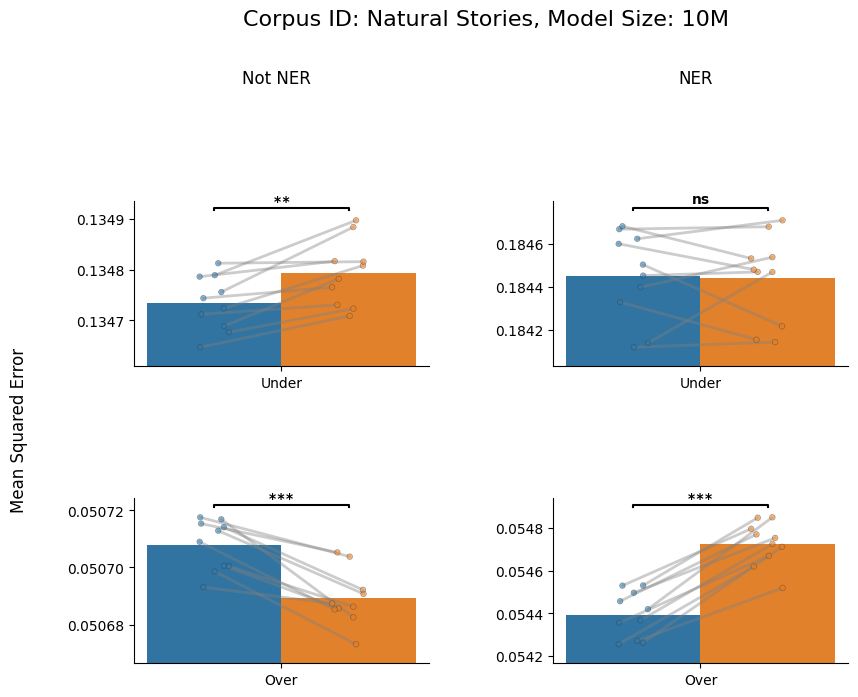

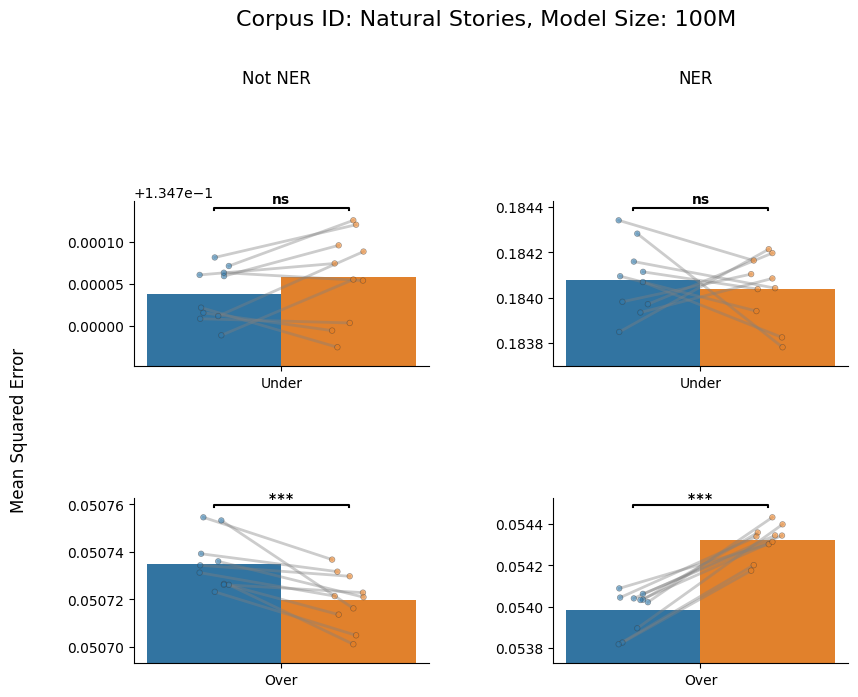

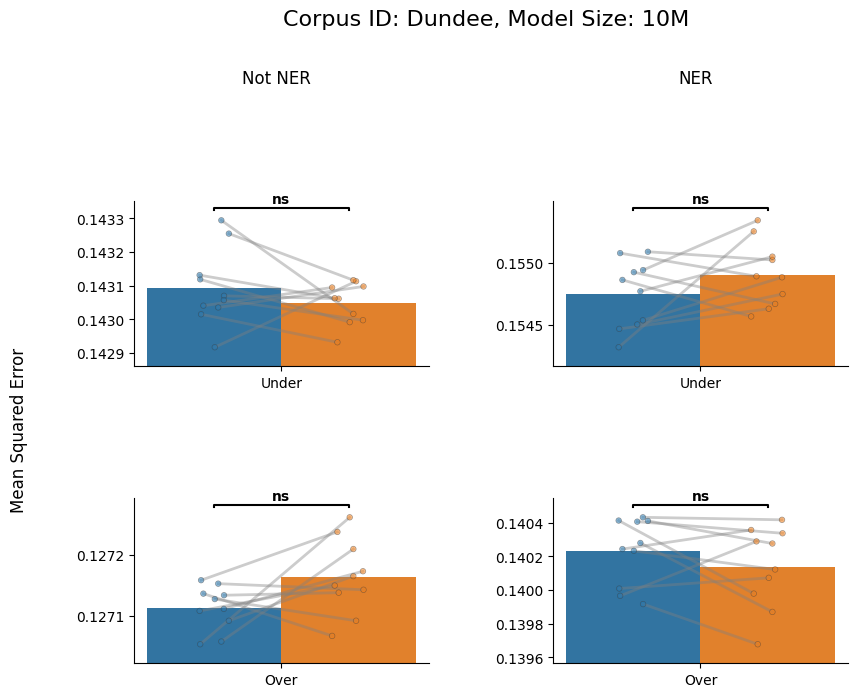

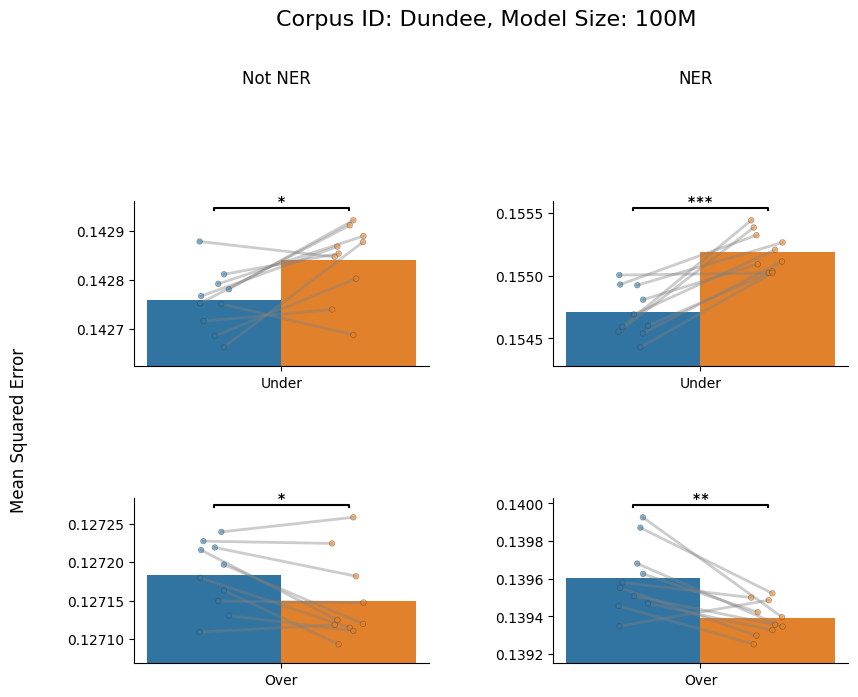

In [159]:

for i, corpus_id in tqdm(enumerate(["Natural Stories", "Dundee"])):
    for j, model_size in tqdm(enumerate(["10M", "100M"])):

        # ax = axes[i, j]
        # index = i * 2 + j
        # ax = axes[index]
        #ax = fig.add_subplot(2, 2, index + 1)
        #Create 11 plots for each POSTag
        # fig, axes = plt.subplots(2, 6, figsize=(16, 8))
        #Create 12 subfigures in 2x6
        fig = plt.figure(figsize=(8, 6))
        subfigs = fig.subfigures(1, 2, wspace=0.1, hspace=0.2)
        #print(subfigs)
        #fig.subplots_adjust(hspace=0.4, wspace=0.6)
        fig.suptitle(f"Corpus ID: {corpus_id}, Model Size: {model_size}", fontsize=16, y = 1.2)
        for k, nergroup in tqdm(enumerate(model_nergroup_underover_df["NERGroup"].unique())):

            #ax = axes[k // 6, k % 6]
            axs = subfigs[k].subplots(2, 1)
            subfigs[k].subplots_adjust(hspace=0.8, wspace=0.6)
            #axs = subfigs[k].subplots(2, 1)
            #Sub fig title
            
            if k == 0 or k == 6:
                subfigs[k].supylabel("Mean Squared Error", x=-0.2)
            
            # subfigs[k].suptitle(f"POSTag: {postag}", fontsize=12)

            for l, uop in enumerate(["Under", "Over"]):
            
                ax = axs[l] 
                # subset = model_under_over_df[(model_under_over_df["CorpusID"] == corpus_id) & (model_under_over_df["Dataset"] == model_size) & (model_under_over_df["POSTag"] == postag) & (model_under_over_df["UOP"] == uop)].copy()

                subset = model_nergroup_underover_df[(model_nergroup_underover_df["CorpusID"] == corpus_id) & (model_nergroup_underover_df["Dataset"] == model_size) & (model_nergroup_underover_df["NERGroup"] == nergroup) & (model_nergroup_underover_df["UOP"] == uop)].copy()
                
                #print(subset)
                #print(subset.shape)
                #print(subset)
                #Make POSTag as not categorical
                subset["NERGroup"] = subset.NERGroup.astype(str)
                subset["UOP"] = subset.UOP.astype(str)
                sns.barplot(x="UOP", y="MeanSquaredError", hue="MaskType", data=subset, ax=ax, errorbar=None)
                sns.stripplot(x="UOP", y="MeanSquaredError", hue="MaskType",  data=subset, ax=ax, dodge=True, alpha=0.5, linewidth=0.5, size=4)
                # ax.set_title(f"POSTag: {postag}")
                
                ax.set_xlabel("")
                if k == 0 or k == 6:
                    # ax.set_ylabel("Sum Squared Error")
                    ax.set_ylabel("")
                else:
                    ax.set_ylabel("")
                
                connect_dots_ib(ax, alpha=0.4, col='grey', linewidth=2)
                # Annotate the plot with significance stars
                #Find Max and Min Y limit as measure of max and and min delta
                max_y = subset["MeanSquaredError"].max()
                min_y = subset["MeanSquaredError"].min()
                ydelta = max_y - min_y
                delta_per = 0.15
                ax.set_ylim(min_y - ydelta * delta_per, max_y + ydelta * delta_per)
                annotate_given_colid_ib_gen(ax, subset, y_frac=0.95, h_frac=0.01, x_col="UOP", pivot_col="MaskType", value_column="MeanSquaredError")
                sns.despine(ax=ax, top=True, right=True)
                # ax.get_legend().remove()
                if k!=10:
                    ax.get_legend().remove()
                else:
                    if l ==1:
                        ax.legend(loc="center right", bbox_to_anchor=(2.5, 0.5))
                    else:
                        ax.get_legend().remove()
            
            subfigs[k].suptitle(f"{nergroup}", fontsize=12, y=1.1)
        #fig.delaxes(axes[1, 5])

        # Save the figure
        plot_name = f"NERGroup_{corpus_id}_{model_size}_underover_separated_MSE.png"
        save_matplot_fig(fig, plot_name, dpi = 1000, folders_path="NERGroup_UnderOver_MSE")

